# Full-Scale 32-Album Parallel Evaluation on Modal
**Qwen/Qwen3-VL-8B-Instruct** | 256 evaluations (32 albums x 8 configs) | 32 parallel containers

| Config | Agents | Deliberation | Round 3 decision |
|---|---|---|---|
| **A** | Musicologist, Market Analyst, A&R Expert | Standard | Ranked-choice vote |
| **B** | Musicologist, Market Analyst, A&R Expert | Standard | A&R decides after hearing peers |
| **C** | + Singer-Songwriter, Private Investor | Standard | Ranked-choice vote |
| **D** | + Singer-Songwriter, Private Investor | Standard | A&R decides after hearing peers |
| **E** | Musicologist, Market Analyst, A&R Expert | Constrained+Directional | Ranked-choice vote |
| **F** | Musicologist, Market Analyst, A&R Expert | Constrained+Directional | A&R decides after hearing peers |
| **G** | + Singer-Songwriter, Private Investor | Constrained+Directional | Ranked-choice vote |
| **H** | + Singer-Songwriter, Private Investor | Constrained+Directional | A&R decides after hearing peers |

**Constrained+Directional (E-H):** R2 must avoid R1 mode; R3 must avoid R1+R2 modes and agents are strongly
encouraged to predict opposite to their own R1->R2 trend.

All agents receive: **textual description | cover image | audio features**
One container per album runs all 8 configs -- model loaded once.

**32 albums** (4 per genre, randomly sampled) -- same inference budget as 64 x 4 configs.

**Statistical note:** Reducing from 64 to 32 albums widens overall 95% CIs from ~12 to ~17 percentage points
but preserves within-album paired comparisons (same 32 albums across all 8 configs), keeping adequate power
for configuration-level comparisons. Genre-level results (n=4/genre) are descriptive only.

In [6]:
%pip install -q modal pillow matplotlib seaborn scipy numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [7]:
import json, os, base64, time, re, warnings, random
from collections import Counter, defaultdict
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('Imports OK')

Imports OK


In [12]:
BASE_FOLDER  = '/Users/river/Desktop/MACS 37005/sampled_albums_with_audio'
JSON_PATH    = os.path.join(BASE_FOLDER, 'albums_dataset.json')
RESULTS_PATH = '/Users/river/Desktop/MACS 37005/fullscale_results.json'
MODEL_NAME   = 'Qwen/Qwen3-VL-8B-Instruct'
A10G_RATE    = 0.76 / 3600
RANDOM_SEED  = 42
N_PER_GENRE  = 4

TIER_DEF = (
    'Tier 1: Underground/Cult  (< 100K plays)\n'
    'Tier 2: Indie Success     (100K-1M plays)\n'
    'Tier 3: Moderate Hit      (1M-10M plays)\n'
    'Tier 4: Major Success     (10M-100M plays)\n'
    'Tier 5: Cultural Phenom   (> 100M plays)'
)

THREE_AGENTS = ['musicologist','market_analyst','ar_expert']
FIVE_AGENTS  = ['musicologist','market_analyst','ar_expert',
                'singer_songwriter','private_investor']

# (key, short_label, colour, n_agents, agents, constrained)
CONFIG_META = [
    ('config_a','A: 3-RC',     '#4C72B0',3,THREE_AGENTS,False),
    ('config_b','B: 3-Hier',   '#DD8452',3,THREE_AGENTS,False),
    ('config_c','C: 5-RC',     '#55A868',5,FIVE_AGENTS, False),
    ('config_d','D: 5-Hier',   '#C44E52',5,FIVE_AGENTS, False),
    ('config_e','E: 3-RC+',    '#8172B2',3,THREE_AGENTS,True),
    ('config_f','F: 3-Hier+',  '#937860',3,THREE_AGENTS,True),
    ('config_g','G: 5-RC+',    '#DA8BC3',5,FIVE_AGENTS, True),
    ('config_h','H: 5-Hier+',  '#64B5CD',5,FIVE_AGENTS, True),
]

AGENT_LABELS = {
    'musicologist':'Musicologist','market_analyst':'Market Analyst',
    'ar_expert':'A&R Expert','singer_songwriter':'Singer-Songwriter',
    'private_investor':'Private Investor',
}
print('Constants loaded')

Constants loaded


In [13]:
def load_albums(jp, bf):
    with open(jp) as f: albums=json.load(f)
    for a in albums:
        if a.get('cover_path'): a['cover_path']=os.path.join(bf,a['cover_path'])
    return albums

def sample_by_genre(albums, n=4, seed=42):
    rng=random.Random(seed); by_g=defaultdict(list)
    for a in albums:
        g=(a.get('metadata',{}).get('all_genres') or ['unknown'])[0]
        by_g[g].append(a)
    out=[]
    for g,grp in sorted(by_g.items()): out.extend(rng.sample(grp,min(n,len(grp))))
    return out

def enc(path):
    try:
        with open(path,'rb') as f: return base64.b64encode(f.read()).decode()
    except: return None

def fmt_audio(tracks):
    if not tracks: return 'No audio features available.'
    return '\n'.join(
        f"Track {t.get('track_number','?')} '{t.get('track_name','?')}': "
        f"energy={t.get('energy','N/A')}, danceability={t.get('danceability','N/A')}, "
        f"acousticness={t.get('acousticness','N/A')}, instrumentalness={t.get('instrumentalness','N/A')}, "
        f"happiness={t.get('happiness','N/A')}, liveness={t.get('liveness','N/A')}, "
        f"speechiness={t.get('speechiness','N/A')}, tempo={t.get('tempo','N/A')} BPM"
        for t in tracks)

def audio_means(album):
    tracks=album['audio_features'].get('tracks',[])
    keys=['energy','danceability','acousticness','instrumentalness',
          'happiness','liveness','speechiness','tempo']
    return {k: round(float(np.mean([t[k] for t in tracks if isinstance(t.get(k),(int,float))])),2)
            if any(isinstance(t.get(k),(int,float)) for t in tracks) else None for k in keys}

def serialize(a):
    return {'album_id':a['album_id'],'artist':a['metadata']['artist'],
            'title':a['metadata']['title'],
            'release_year':a['metadata'].get('release_year',''),
            'genres':a['metadata'].get('all_genres',[])[:3],
            'description':a['metadata'].get('description',''),
            'ground_truth':a['ground_truth']['tier'],
            'audio_text':fmt_audio(a['audio_features'].get('tracks',[])),
            'audio_means':audio_means(a),
            'cover_b64':enc(a.get('cover_path',''))}

print('Data helpers defined')

Data helpers defined


## Modal Setup

In [23]:
import modal
app       = modal.App('music-qwen-v2')
model_vol = modal.Volume.from_name('qwen-model-cache', create_if_missing=True)
image = (
    modal.Image.debian_slim(python_version='3.11')
    .pip_install(
        'transformers>=4.51.0', 'accelerate>=1.6.0',
        'torch==2.6.0', 'torchvision',
        'pillow', 'qwen-vl-utils',
    )
)
print('Modal app defined')


Modal app defined


In [24]:
@app.function(
    image=image, gpu=modal.gpu.A10G(),
    volumes={'/model-cache': model_vol},
    timeout=5400, retries=1,
)
def evaluate_all_configs(d: dict) -> dict:
    import re, time, base64, io
    from collections import Counter
    import torch
    from transformers import AutoModelForImageTextToText, AutoProcessor
    from qwen_vl_utils import process_vision_info
    from PIL import Image

    TIER_DEF = (
        'Tier 1: Underground/Cult  (< 100K plays)\n'
        'Tier 2: Indie Success     (100K-1M plays)\n'
        'Tier 3: Moderate Hit      (1M-10M plays)\n'
        'Tier 4: Major Success     (10M-100M plays)\n'
        'Tier 5: Cultural Phenom   (> 100M plays)'
    )
    AGENT_DEFS = {
        'musicologist':('a musicologist',
            'musical merit, production quality, sonic characteristics, and genre conventions'),
        'market_analyst':('a market research analyst',
            'visual branding on the cover, commercial appeal, and market positioning'),
        'ar_expert':('an A&R executive',
            'synthesising artistic merit and commercial potential across all signals'),
        'singer_songwriter':('a professional singer-songwriter and recording artist',
            'lyrical craft, melodic memorability, artistic authenticity, emotional resonance, '
            'and how fellow musicians and devoted fans would receive this album'),
        'private_investor':('a private equity investor specialising in music rights',
            'streaming revenue potential, fanbase scalability, sync-licensing opportunities, '
            'brand longevity, and return on investment for a label or rights portfolio'),
    }
    t0 = time.time()

    # ── Load model once ───────────────────────────────────────────────────────
    model = AutoModelForImageTextToText.from_pretrained(
        'Qwen/Qwen3-VL-8B-Instruct',
        torch_dtype=torch.bfloat16,
        device_map='auto',
        cache_dir='/model-cache',
    )
    processor = AutoProcessor.from_pretrained(
        'Qwen/Qwen3-VL-8B-Instruct', cache_dir='/model-cache')

    cover_img = None
    if d.get('cover_b64'):
        try: cover_img = Image.open(io.BytesIO(base64.b64decode(d['cover_b64']))).convert('RGB')
        except: pass

    def infer(prompt):
        content = []
        if cover_img: content.append({'type':'image','image':cover_img})
        content.append({'type':'text','text':prompt})
        msgs = [{'role':'user','content':content}]
        txt = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        ii, vi = process_vision_info(msgs)
        inp = processor(text=[txt],images=ii,videos=vi,padding=True,return_tensors='pt').to('cuda')
        with torch.no_grad():
            out = model.generate(**inp, max_new_tokens=400, do_sample=False)
        r = processor.batch_decode(out, skip_special_tokens=True)[0]
        return r.split('assistant')[-1].strip() if 'assistant' in r.lower() else r

    def parse(text, want_rank=False):
        tier=rank=None; arg=''
        for line in text.split('\n'):
            ls=line.strip()
            if ls.startswith('TIER:'):
                m=re.search(r'(\d)',ls.split('TIER:',1)[1])
                if m: tier=int(m.group(1))
            elif ls.startswith('RANKING:'):
                try: rank=[int(x.strip()) for x in ls.split('RANKING:',1)[1].split(',')]
                except: pass
            elif ls.startswith('ARGUMENT:'): arg=ls.split('ARGUMENT:',1)[1].strip()
        if not arg: arg=text[:200]
        if want_rank:
            if not rank:
                m=re.search(r'(\d)[,\s]+(\d)[,\s]+(\d)[,\s]+(\d)[,\s]+(\d)',text)
                if m: rank=[int(x) for x in m.groups()]
            return {'ranking':rank,'tier':rank[0] if rank else (tier or 3),'argument':arg}
        if tier is None:
            m=re.search(r'\bTier\s*(\d)',text,re.IGNORECASE)
            if m: tier=int(m.group(1))
        return {'tier':tier or 3,'argument':arg}

    def ranked_choice(rankings):
        valid=[r for r in rankings if r and len(r)==5]
        if not valid: return 3
        tiers=list(range(1,6))
        while len(tiers)>1:
            votes=Counter()
            for r in valid:
                for t in r:
                    if t in tiers: votes[t]+=1; break
            for t,c in votes.items():
                if c>len(valid)/2: return t
            if not votes: break
            lo=min(votes.values())
            for t in [t for t,v in votes.items() if v==lo]:
                if t in tiers: tiers.remove(t); break
        return tiers[0] if tiers else valid[0][0]

    def hist_text(history, agents):
        lines=[]
        for r in history:
            lines.append(f"Round {r['round']}:")
            for ag in agents:
                lines.append(f"  {ag.replace('_',' ').title():<22} Tier {r[ag]['tier']}: {r[ag]['argument'][:110]}")
        return '\n'.join(lines)

    # ── Standard prompt builders (A-D) ───────────────────────────────────────
    def std_prompt(role, rnd, ht, rc_final=False):
        identity,focus = AGENT_DEFS[role]
        body = (f'You are {identity} predicting commercial success of an album.\n\n'
                f'Artist: {d["artist"]}  |  Title: {d["title"]}  |  Year: {d["release_year"]}\n'
                f'Genres: {", ".join(d["genres"])}\nDescription: {d["description"]}\n\n'
                f'Audio Features (0-100 scale, tempo in BPM):\n{d["audio_text"]}\n\n'
                f'{TIER_DEF}\n\nYour evaluation lens: {focus}\n\nRound {rnd}/3.')
        if ht: body += f'\n\nPrior rounds:\n{ht}'
        body += ('\n\nRANK all 5 tiers most to least likely. EXACT format:\n'
                 'RANKING: [e.g. 3,4,2,5,1]\nARGUMENT: [~80 words]') if rc_final else (
                 '\n\nPredict ONE tier. EXACT format:\nTIER: [1-5]\nARGUMENT: [~80 words]')
        return body

    def std_ar_hier(ht, peer_results, peers):
        body = (f'You are an A&R executive making the FINAL tier prediction.\n\n'
                f'Artist: {d["artist"]}  |  Title: {d["title"]}\nDescription: {d["description"]}\n\n'
                f'Audio:\n{d["audio_text"]}\n\n{TIER_DEF}\n\nPrior rounds:\n{ht}\n\n'
                '--- Round 3 Opinions ---\n')
        for p in peers:
            body += f'{p.replace("_"," ").title()} predicts Tier {peer_results[p]["tier"]}: {peer_results[p]["argument"]}\n\n'
        body += 'Give your FINAL verdict.\nEXACT format:\nTIER: [1-5]\nARGUMENT: [~80 words]'
        return body

    # ── Constrained+Directional helpers (E-H) ────────────────────────────────
    def compute_mode(rdata, agents):
        tiers=[rdata[ag]['tier'] for ag in agents if isinstance(rdata[ag].get('tier'),int)]
        if not tiers: return []
        counts=Counter(tiers); mx=max(counts.values())
        return sorted(t for t,c in counts.items() if c==mx)

    def excl_line(modes, rc_final=False, label='the previous round'):
        if not modes: return ''
        ts=' and '.join(f'Tier {t}' for t in modes)
        return (f'\n\nCONSTRAINT: Your FIRST choice MUST NOT be {ts} '
                f'(most common in {label}). Lower-ranked choices are unconstrained.'
                if rc_final else
                f'\n\nCONSTRAINT: You MUST NOT predict {ts} '
                f'(most common in {label}). Choose any other tier.')

    def dir_line(r1, r2, rc_final=False):
        if r1 is None or r2 is None or r1==r2: return ''
        subj='your FIRST CHOICE is' if rc_final else 'you are'
        if r2<r1:
            return (f'\n\nDIRECTIONAL SUGGESTION: Your predictions trended downward '
                    f'(Tier {r1} to Tier {r2}). To counter anchoring bias, '
                    f'{subj} strongly encouraged to consider a tier strictly higher '
                    f'than both prior predictions (above Tier {r1}).')
        return (f'\n\nDIRECTIONAL SUGGESTION: Your predictions trended upward '
                f'(Tier {r1} to Tier {r2}). To counter anchoring bias, '
                f'{subj} strongly encouraged to consider a tier strictly lower '
                f'than both prior predictions (below Tier {r1}).')

    def cd_prompt(role, rnd, ht, rc_final=False,
                  exc=None, elabel='the previous round', r1=None, r2=None):
        identity,focus = AGENT_DEFS[role]
        body = (f'You are {identity} predicting commercial success of an album.\n\n'
                f'Artist: {d["artist"]}  |  Title: {d["title"]}  |  Year: {d["release_year"]}\n'
                f'Genres: {", ".join(d["genres"])}\nDescription: {d["description"]}\n\n'
                f'Audio Features (0-100 scale, tempo in BPM):\n{d["audio_text"]}\n\n'
                f'{TIER_DEF}\n\nYour evaluation lens: {focus}\n\nRound {rnd}/3.')
        if ht: body += f'\n\nPrior rounds:\n{ht}'
        if exc: body += excl_line(exc, rc_final=rc_final, label=elabel)
        if r1 is not None and r2 is not None: body += dir_line(r1, r2, rc_final=rc_final)
        body += ('\n\nRANK all 5 tiers most to least likely. EXACT format:\n'
                 'RANKING: [e.g. 3,4,2,5,1]\nARGUMENT: [~80 words]') if rc_final else (
                 '\n\nPredict ONE tier. EXACT format:\nTIER: [1-5]\nARGUMENT: [~80 words]')
        return body

    def cd_ar_hier(ht, peer_results, peers, exc=None, elabel='the previous round', r1=None, r2=None):
        body = (f'You are an A&R executive making the FINAL tier prediction.\n\n'
                f'Artist: {d["artist"]}  |  Title: {d["title"]}\nDescription: {d["description"]}\n\n'
                f'Audio:\n{d["audio_text"]}\n\n{TIER_DEF}\n\nPrior rounds:\n{ht}\n\n'
                '--- Round 3 Opinions ---\n')
        for p in peers:
            body += f'{p.replace("_"," ").title()} predicts Tier {peer_results[p]["tier"]}: {peer_results[p]["argument"]}\n\n'
        if exc: body += excl_line(exc, label=elabel)
        if r1 is not None and r2 is not None: body += dir_line(r1, r2)
        body += 'Give your FINAL verdict.\nEXACT format:\nTIER: [1-5]\nARGUMENT: [~80 words]'
        return body

    # ── Standard runners ──────────────────────────────────────────────────────
    def run_rc(agents):
        history=[]
        for rnd in range(1,4):
            is_f=(rnd==3); ht=hist_text(history,agents); rd={'round':rnd}
            for ag in agents:
                rd[ag]=parse(infer(std_prompt(ag,rnd,ht,rc_final=is_f)),want_rank=is_f)
            history.append(rd)
        fr=[history[2][ag].get('ranking') for ag in agents]
        return {'final_prediction':ranked_choice(fr),'conversation':history,
                'final_rankings':fr,'round_modes':{}}

    def run_hier(agents, da='ar_expert'):
        peers=[ag for ag in agents if ag!=da]; history=[]
        for rnd in range(1,4):
            is_f=(rnd==3); ht=hist_text(history,agents); rd={'round':rnd}
            if is_f:
                for ag in peers: rd[ag]=parse(infer(std_prompt(ag,rnd,ht)))
                rd[da]=parse(infer(std_ar_hier(ht,rd,peers)))
            else:
                for ag in agents: rd[ag]=parse(infer(std_prompt(ag,rnd,ht)))
            history.append(rd)
        return {'final_prediction':history[2][da]['tier'],'conversation':history,
                'final_rankings':None,'round_modes':{}}

    # ── Constrained+Directional runners ──────────────────────────────────────
    def run_rc_cd(agents):
        history=[]; rm={}
        for rnd in range(1,4):
            is_f=(rnd==3); ht=hist_text(history,agents); rd={'round':rnd}
            exc=(rm.get(1,[]) if rnd==2 else
                 sorted(set(rm.get(1,[])+rm.get(2,[]))) if rnd==3 else [])
            elabel='round 1' if rnd==2 else 'rounds 1 and 2' if rnd==3 else ''
            for ag in agents:
                r1=history[0][ag]['tier'] if rnd==3 and len(history)>=2 else None
                r2=history[1][ag]['tier'] if rnd==3 and len(history)>=2 else None
                rd[ag]=parse(infer(cd_prompt(ag,rnd,ht,rc_final=is_f,
                    exc=exc if rnd>1 else None,elabel=elabel,r1=r1,r2=r2)),want_rank=is_f)
            history.append(rd); rm[rnd]=compute_mode(rd,agents)
        fr=[history[2][ag].get('ranking') for ag in agents]
        return {'final_prediction':ranked_choice(fr),'conversation':history,
                'final_rankings':fr,'round_modes':rm}

    def run_hier_cd(agents, da='ar_expert'):
        peers=[ag for ag in agents if ag!=da]; history=[]; rm={}
        for rnd in range(1,4):
            is_f=(rnd==3); ht=hist_text(history,agents); rd={'round':rnd}
            exc=(rm.get(1,[]) if rnd==2 else
                 sorted(set(rm.get(1,[])+rm.get(2,[]))) if rnd==3 else [])
            elabel='round 1' if rnd==2 else 'rounds 1 and 2' if rnd==3 else ''
            if is_f:
                for ag in peers:
                    r1=history[0][ag]['tier'] if len(history)>=2 else None
                    r2=history[1][ag]['tier'] if len(history)>=2 else None
                    rd[ag]=parse(infer(cd_prompt(ag,rnd,ht,exc=exc,elabel=elabel,r1=r1,r2=r2)))
                r1d=history[0][da]['tier'] if len(history)>=2 else None
                r2d=history[1][da]['tier'] if len(history)>=2 else None
                rd[da]=parse(infer(cd_ar_hier(ht,rd,peers,exc=exc,elabel=elabel,r1=r1d,r2=r2d)))
            else:
                for ag in agents:
                    rd[ag]=parse(infer(cd_prompt(ag,rnd,ht,
                        exc=exc if rnd>1 else None,elabel=elabel)))
            history.append(rd); rm[rnd]=compute_mode(rd,agents)
        return {'final_prediction':history[2][da]['tier'],'conversation':history,
                'final_rankings':None,'round_modes':rm}

    THREE=['musicologist','market_analyst','ar_expert']
    FIVE=['musicologist','market_analyst','ar_expert','singer_songwriter','private_investor']

    cfg_a=run_rc(THREE);    cfg_b=run_hier(THREE)
    cfg_c=run_rc(FIVE);     cfg_d=run_hier(FIVE)
    cfg_e=run_rc_cd(THREE); cfg_f=run_hier_cd(THREE)
    cfg_g=run_rc_cd(FIVE);  cfg_h=run_hier_cd(FIVE)

    runtime=round(time.time()-t0,2)
    return {
        'album_id':d['album_id'],'album_label':f"{d['artist']} - {d['title']}",
        'ground_truth':d['ground_truth'],'genres':d['genres'],'audio_means':d['audio_means'],
        'config_a':cfg_a,'config_b':cfg_b,'config_c':cfg_c,'config_d':cfg_d,
        'config_e':cfg_e,'config_f':cfg_f,'config_g':cfg_g,'config_h':cfg_h,
        'runtime_s':runtime,'gpu_cost_usd':round(runtime*(0.76/3600),5),
    }

print('Modal function defined (8 configs)')


Modal function defined (8 configs)


## Load, Sample & Run

In [10]:
albums_raw    = load_albums(JSON_PATH, BASE_FOLDER)
albums_sample = sample_by_genre(albums_raw, n=N_PER_GENRE, seed=RANDOM_SEED)
albums_serial = [serialize(a) for a in albums_sample]
gc = Counter((a.get('metadata',{}).get('all_genres') or ['unknown'])[0] for a in albums_sample)
print(f'Sampled {len(albums_serial)} albums | Genre breakdown: {dict(sorted(gc.items()))}')

Sampled 35 albums | Genre breakdown: {'alternative metal': 1, 'alternative rock': 1, 'ambient': 4, 'blues rock': 1, 'britpop': 1, 'celtic': 1, 'downtempo': 1, 'folk': 1, 'futurepop': 1, 'hard rock': 1, 'hip hop': 4, 'indie rock': 1, 'jazz': 1, 'orchestra': 1, 'pop': 1, 'pop folk': 2, 'pop rock': 4, 'pop soul': 1, 'rock': 1, 'rock and roll': 1, 'shoegaze': 1, 'singer-songwriter': 1, 'symphonic metal': 1, 'synthpop': 1, 'techno': 1}


### ⚡ Warm-up
Triggers a single container to pre-download model weights into the volume (~5–10 min, free after first time).
Also confirms Flash Attention 2 loaded correctly.

In [26]:
# WARM-UP: run this cell once to pre-cache model weights in the Modal volume.
# After it completes successfully, skip this cell and run the full-run cell below.
print('Starting warm-up with 1 album...')
async with app.run():
    async for result in evaluate_all_configs.map.aio(albums_serial[:1]):
        print(f'  Warm-up complete: {result["album_id"]} | runtime={result["runtime_s"]:.0f}s')
print('Volume is warm. Proceed to the full run cell.')


Starting warm-up with 1 album...
  Warm-up complete: 032 | runtime=571s
Volume is warm. Proceed to the full run cell.


In [27]:
all_results=[]; wall_start=time.time()
print('Submitting 32 containers (8 configs each)...')
KEYS=['config_a','config_b','config_c','config_d','config_e','config_f','config_g','config_h']

CHECKPOINT_PATH = RESULTS_PATH.replace('.json', '_checkpoint.jsonl')
_ckpt_file = open(CHECKPOINT_PATH, 'w')

async with app.run():
    async for result in evaluate_all_configs.map.aio(albums_serial, order_outputs=False):
        all_results.append(result)
        _ckpt_file.write(json.dumps(result) + '\n')
        _ckpt_file.flush()
        row=' '.join(f'{k[-1].upper()}:{result[k]["final_prediction"]}' for k in KEYS)
        print(f'  [{result["album_id"]}] GT:{result["ground_truth"]} | {row} | '
              f'{result["runtime_s"]:.0f}s ${result["gpu_cost_usd"]:.3f}')

_ckpt_file.close()
wall_time=time.time()-wall_start
print(f'Done in {wall_time:.0f}s ({wall_time/60:.1f} min) | {len(all_results)}/32 completed')


Submitting 32 containers (8 configs each)...
  [032] GT:2 | A:4 B:4 C:4 D:4 E:2 F:3 G:2 H:2 | 508s $0.107
  [028] GT:3 | A:2 B:2 C:2 D:2 E:1 F:1 G:4 H:3 | 499s $0.105
  [060] GT:3 | A:4 B:3 C:3 D:4 E:1 F:2 G:1 H:1 | 511s $0.108
  [062] GT:3 | A:3 B:3 C:2 D:2 E:1 F:1 G:1 H:1 | 497s $0.105
  [034] GT:3 | A:2 B:2 C:2 D:2 E:1 F:1 G:1 H:1 | 526s $0.111
  [024] GT:2 | A:4 B:4 C:4 D:4 E:1 F:2 G:1 H:2 | 499s $0.105
  [039] GT:2 | A:3 B:3 C:2 D:2 E:1 F:1 G:1 H:1 | 520s $0.110
  [011] GT:3 | A:3 B:3 C:3 D:3 E:1 F:1 G:1 H:1 | 530s $0.112
  [047] GT:3 | A:3 B:3 C:3 D:3 E:1 F:1 G:4 H:4 | 527s $0.111
  [031] GT:2 | A:4 B:4 C:5 D:4 E:2 F:3 G:2 H:3 | 531s $0.112
  [022] GT:2 | A:4 B:4 C:4 D:5 E:1 F:2 G:5 H:5 | 500s $0.106
  [017] GT:2 | A:3 B:3 C:4 D:4 E:1 F:1 G:5 H:2 | 519s $0.110
  [015] GT:3 | A:3 B:3 C:3 D:3 E:4 F:2 G:4 H:1 | 527s $0.111
  [029] GT:3 | A:2 B:2 C:2 D:2 E:1 F:1 G:4 H:3 | 540s $0.114
  [030] GT:2 | A:3 B:3 C:2 D:2 E:1 F:1 G:1 H:1 | 513s $0.108
  [051] GT:1 | A:3 B:3 C:2 D:2 E:1 F:1 G

[modal-client] 2026-03-13T02:07:29-0500 Warning: the results of a call to Function.map.aio was not consumed, so the call will never be executed. Consider a for-loop like `for x in Function.map.aio(...)` or unpacking the generator using `list(...)`


  [014] GT:4 | A:4 B:4 C:4 D:4 E:1 F:2 G:1 H:2 | 532s $0.112
  [019] GT:2 | A:3 B:3 C:3 D:3 E:1 F:2 G:2 H:1 | 518s $0.109
  [056] GT:1 | A:1 B:1 C:1 D:1 E:1 F:1 G:5 H:3 | 531s $0.112
  [009] GT:3 | A:3 B:3 C:3 D:3 E:2 F:1 G:1 H:1 | 538s $0.114
  [026] GT:3 | A:1 B:1 C:1 D:1 E:1 F:1 G:5 H:1 | 498s $0.105
  [023] GT:2 | A:3 B:3 C:3 D:3 E:1 F:1 G:1 H:1 | 501s $0.106
  [044] GT:2 | A:3 B:3 C:3 D:3 E:1 F:1 G:1 H:1 | 512s $0.108
  [035] GT:2 | A:3 B:3 C:3 D:3 E:2 F:1 G:2 H:1 | 523s $0.110
  [010] GT:3 | A:4 B:4 C:4 D:4 E:5 F:5 G:2 H:2 | 522s $0.110
Done in 2113s (35.2 min) | 35/32 completed


In [28]:
with open(RESULTS_PATH,'w') as f:
    json.dump({'results':all_results,'wall_time_s':round(wall_time,2),
               'model':MODEL_NAME,'n_albums':len(albums_serial)},f,indent=2)
print(f'Saved -> {RESULTS_PATH}')

Saved -> /Users/river/Desktop/MACS 37005/fullscale_results.json


---
# Analysis

All sections use the same `CONFIG_META` list, so they automatically cover all 8 configs.

In [31]:
if not all_results:
    # Try full results first, fall back to incremental checkpoint
    if os.path.exists(RESULTS_PATH):
        saved=json.load(open(RESULTS_PATH))
        all_results=saved['results']; wall_time=saved.get('wall_time_s',0)
        print(f'Loaded {len(all_results)} albums from {RESULTS_PATH}')
    else:
        ckpt=RESULTS_PATH.replace('.json','_checkpoint.jsonl')
        if os.path.exists(ckpt):
            with open(ckpt) as f:
                all_results=[json.loads(l) for l in f if l.strip()]
            wall_time=0
            print(f'Loaded {len(all_results)} albums from checkpoint (run may be incomplete)')
        else:
            raise FileNotFoundError('No results found — run the evaluation cell first.')
else:
    print(f'{len(all_results)} albums already in memory')

KEYS=['config_a','config_b','config_c','config_d','config_e','config_f','config_g','config_h']

def flat(results, k):
    return [{'album_id':r['album_id'],'album_label':r['album_label'],
             'ground_truth':r['ground_truth'],'genres':r['genres'],
             'audio_means':r['audio_means'],
             'final_prediction':r[k]['final_prediction'],
             'conversation':r[k]['conversation'],
             'final_rankings':r[k].get('final_rankings'),
             'round_modes':r[k].get('round_modes',{})} for r in all_results]

def metrics(rlist):
    errs=[abs(r['final_prediction']-r['ground_truth']) for r in rlist]
    n=len(errs)
    return {'accuracy':sum(e==0 for e in errs)/n*100,
            'off_by_one':sum(e<=1 for e in errs)/n*100,
            'mae':float(np.mean(errs)),'rmse':float(np.sqrt(np.mean(np.array(errs)**2))),
            'errors':errs,'n':n}

# Map sub-genres → parent genres for cleaner analysis grouping
_PARENT_MAP = {
    # pop
    'pop rock':'pop','pop folk':'pop','futurepop':'pop','pop soul':'pop',
    'britpop':'pop','synthpop':'pop','electropop':'pop','dance pop':'pop',
    'indie pop':'pop','synth-pop':'pop','chamber pop':'pop','baroque pop':'pop',
    # rock
    'rock and roll':'rock','blues rock':'rock','indie rock':'rock',
    'alternative rock':'rock','hard rock':'rock','shoegaze':'rock',
    'psychedelic rock':'rock','classic rock':'rock','punk rock':'rock',
    'post-punk':'rock','new wave':'rock','art rock':'rock',
    # metal
    'alternative metal':'metal','symphonic metal':'metal','heavy metal':'metal',
    'death metal':'metal','black metal':'metal','doom metal':'metal',
    # electronic
    'ambient':'electronic','downtempo':'electronic','techno':'electronic',
    'house':'electronic','edm':'electronic','idm':'electronic',
    'trip-hop':'electronic','drum and bass':'electronic',
    # folk
    'singer-songwriter':'folk','celtic':'folk','folk rock':'folk',
    'americana':'folk','bluegrass':'folk',
    # classical
    'orchestra':'classical','orchestral':'classical','chamber music':'classical',
    'contemporary classical':'classical','neoclassical':'classical',
    # r&b / soul
    'soul':'r&b','neo soul':'r&b','funk':'r&b',
}

def pgenre(r):
    g = r.get('genres', [])
    raw = (g[0] if g else 'unknown').lower().strip()
    return _PARENT_MAP.get(raw, raw)

def get_tier(r,ri,ag): return r['conversation'][ri][ag]['tier']

cfg_flat={k:flat(all_results,k) for k in KEYS}
cfg_mets={k:metrics(cfg_flat[k]) for k in KEYS}

print(f'{"Config":<18} {"Acc":>7} {"Off-1":>7} {"MAE":>7} {"RMSE":>7}')
print('-'*45)
for k,label,*_ in CONFIG_META:
    m=cfg_mets[k]
    print(f'{label:<18} {m["accuracy"]:>6.1f}% {m["off_by_one"]:>6.1f}% {m["mae"]:>7.2f} {m["rmse"]:>7.2f}')


35 albums already in memory
Config                 Acc   Off-1     MAE    RMSE
---------------------------------------------
A: 3-RC              31.4%   77.1%    0.94    1.23
B: 3-Hier            31.4%   74.3%    0.97    1.26
C: 5-RC              34.3%   74.3%    0.97    1.31
D: 5-Hier            31.4%   74.3%    1.03    1.37
E: 3-RC+             14.3%   48.6%    1.46    1.70
F: 3-Hier+           14.3%   51.4%    1.43    1.67
G: 5-RC+             14.3%   57.1%    1.49    1.80
H: 5-Hier+           20.0%   60.0%    1.31    1.62


## 1 · Overall Accuracy — All 8 Configurations

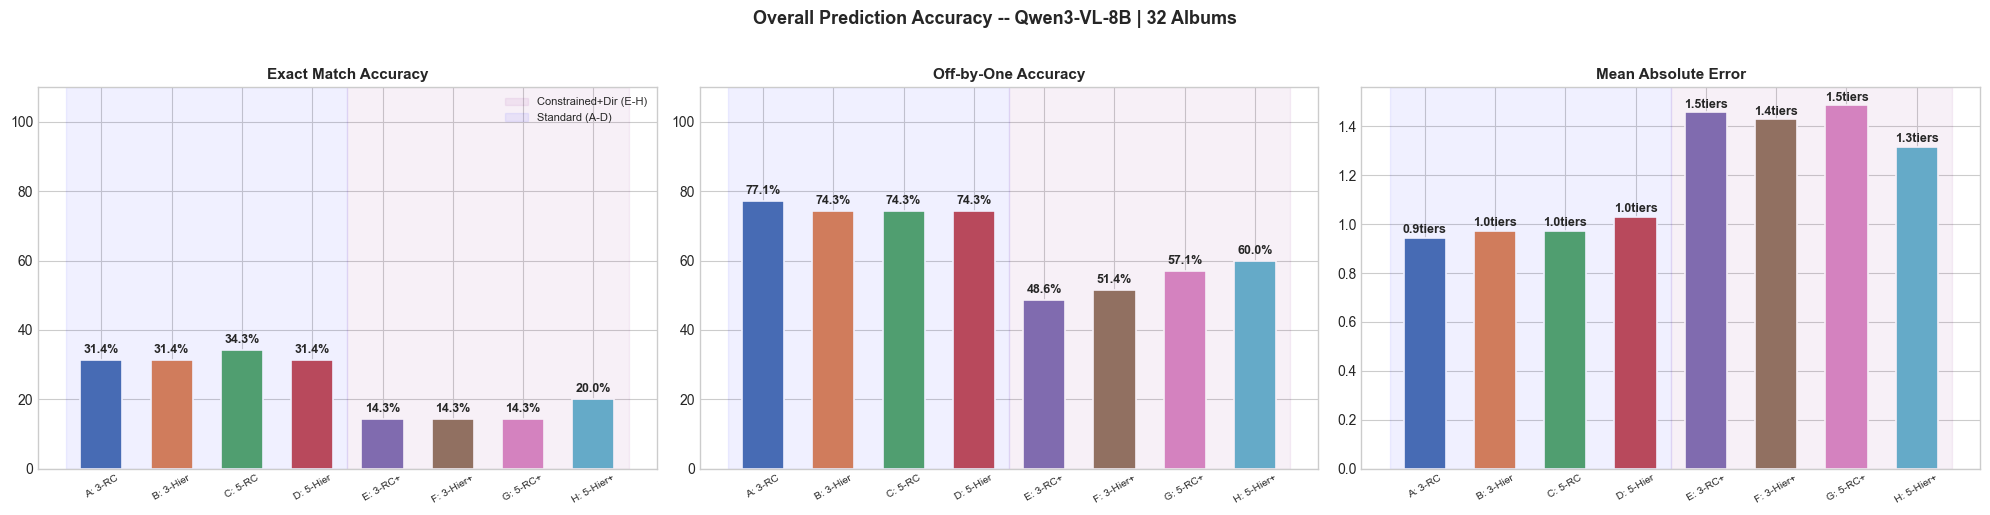

Avg accuracy  -- Standard: 32.1%   Constrained+Dir: 15.7%
Avg MAE       -- Standard: 0.98    Constrained+Dir: 1.42


In [30]:
labels=[lbl for _,lbl,*_ in CONFIG_META]
cols  =[col for _,_,col,*_ in CONFIG_META]

fig,axes=plt.subplots(1,3,figsize=(20,5))
for ax,(mk,title,unit,ylim) in zip(axes,[
    ('accuracy','Exact Match Accuracy','%',(0,110)),
    ('off_by_one','Off-by-One Accuracy','%',(0,110)),
    ('mae','Mean Absolute Error','tiers',None)]):
    vals=[cfg_mets[k][mk] for k,*_ in CONFIG_META]
    bars=ax.bar(labels,vals,color=cols,width=0.6,edgecolor='white',linewidth=1.2)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+(2 if unit=='%' else 0.02),
                f'{v:.1f}{unit}',ha='center',fontsize=9,fontweight='bold')
    if ylim: ax.set_ylim(*ylim)
    ax.set_title(title,fontsize=11,fontweight='bold')
    ax.tick_params(axis='x',labelsize=7.5,rotation=30)

# shade standard vs constrained
for ax in axes:
    ax.axvspan(3.5,7.5,alpha=0.06,color='purple',label='Constrained+Dir (E-H)')
    ax.axvspan(-0.5,3.5,alpha=0.06,color='blue',label='Standard (A-D)')

plt.suptitle('Overall Prediction Accuracy -- Qwen3-VL-8B | 32 Albums',
             fontsize=13,fontweight='bold',y=1.02)
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

# Standard vs Constrained+Directional summary
std_acc =np.mean([cfg_mets[k]['accuracy']   for k in ['config_a','config_b','config_c','config_d']])
cd_acc  =np.mean([cfg_mets[k]['accuracy']   for k in ['config_e','config_f','config_g','config_h']])
std_mae =np.mean([cfg_mets[k]['mae']         for k in ['config_a','config_b','config_c','config_d']])
cd_mae  =np.mean([cfg_mets[k]['mae']         for k in ['config_e','config_f','config_g','config_h']])
print(f'Avg accuracy  -- Standard: {std_acc:.1f}%   Constrained+Dir: {cd_acc:.1f}%')
print(f'Avg MAE       -- Standard: {std_mae:.2f}    Constrained+Dir: {cd_mae:.2f}')

## 2 · Accuracy by Genre

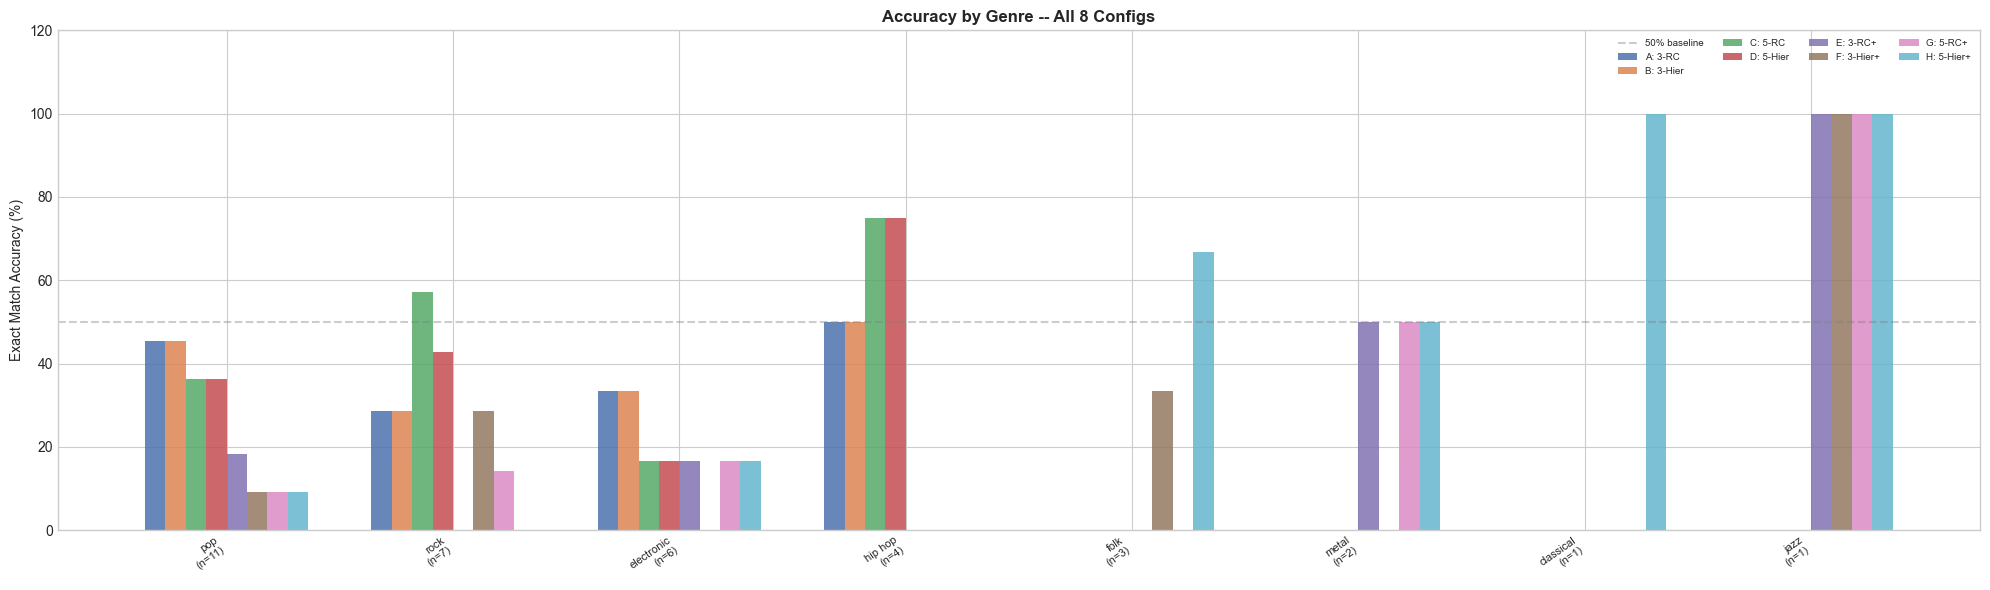

Genre               A: 3-RC  B: 3-Hi  C: 5-RC  D: 5-Hi  E: 3-RC  F: 3-Hi  G: 5-RC  H: 5-Hi
----------------------------------------------------------------------------------------
pop                     45%      45%      36%      36%      18%       9%       9%       9%
rock                    29%      29%      57%      43%       0%      29%      14%       0%
electronic              33%      33%      17%      17%      17%       0%      17%      17%
hip hop                 50%      50%      75%      75%       0%       0%       0%       0%
folk                     0%       0%       0%       0%       0%      33%       0%      67%
metal                    0%       0%       0%       0%      50%       0%      50%      50%
classical                0%       0%       0%       0%       0%       0%       0%     100%
jazz                     0%       0%       0%       0%     100%     100%     100%     100%


In [32]:
all_genres=sorted(set(pgenre(r) for r in all_results),
                  key=lambda g:-sum(1 for r in all_results if pgenre(r)==g))

def genre_acc(k):
    d=defaultdict(list)
    for r in cfg_flat[k]: d[pgenre(r)].append(abs(r['final_prediction']-r['ground_truth']))
    return {g:(sum(e==0 for e in v)/len(v)*100,np.mean(v)) for g,v in d.items()}

g_acc={k:genre_acc(k) for k in KEYS}
x=np.arange(len(all_genres)); w=0.09; offs=np.linspace(-3.5*w,3.5*w,8)

fig,ax=plt.subplots(figsize=(20,6))
for (k,lbl,col,*_),off in zip(CONFIG_META,offs):
    vals=[g_acc[k].get(g,(0,0))[0] for g in all_genres]
    ax.bar(x+off,vals,w,label=lbl,color=col,alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'{g}\n(n={sum(1 for r in all_results if pgenre(r)==g)})'
                    for g in all_genres],rotation=35,ha='right',fontsize=8)
ax.set_ylabel('Exact Match Accuracy (%)'); ax.set_ylim(0,120)
ax.axhline(50,color='grey',ls='--',alpha=0.4,label='50% baseline')
ax.set_title('Accuracy by Genre -- All 8 Configs',fontsize=12,fontweight='bold')
ax.legend(fontsize=7,ncol=4,loc='upper right'); plt.tight_layout(); plt.show()

# table
print(f"{'Genre':<18}", end='')
for _,lbl,*_ in CONFIG_META: print(f'{lbl[:7]:>9}',end='')
print()
print('-'*88)
for g in all_genres:
    print(f'{g:<18}',end='')
    for k,*_ in CONFIG_META: print(f'{g_acc[k].get(g,(0,0))[0]:>8.0f}%',end='')
    print()

## 3 · Convergence Analysis

One subplot per config (4x2 grid). Each coloured line = one agent's round-by-round mean tier.
Orange line = panel mean; dashed green = mean ground truth.

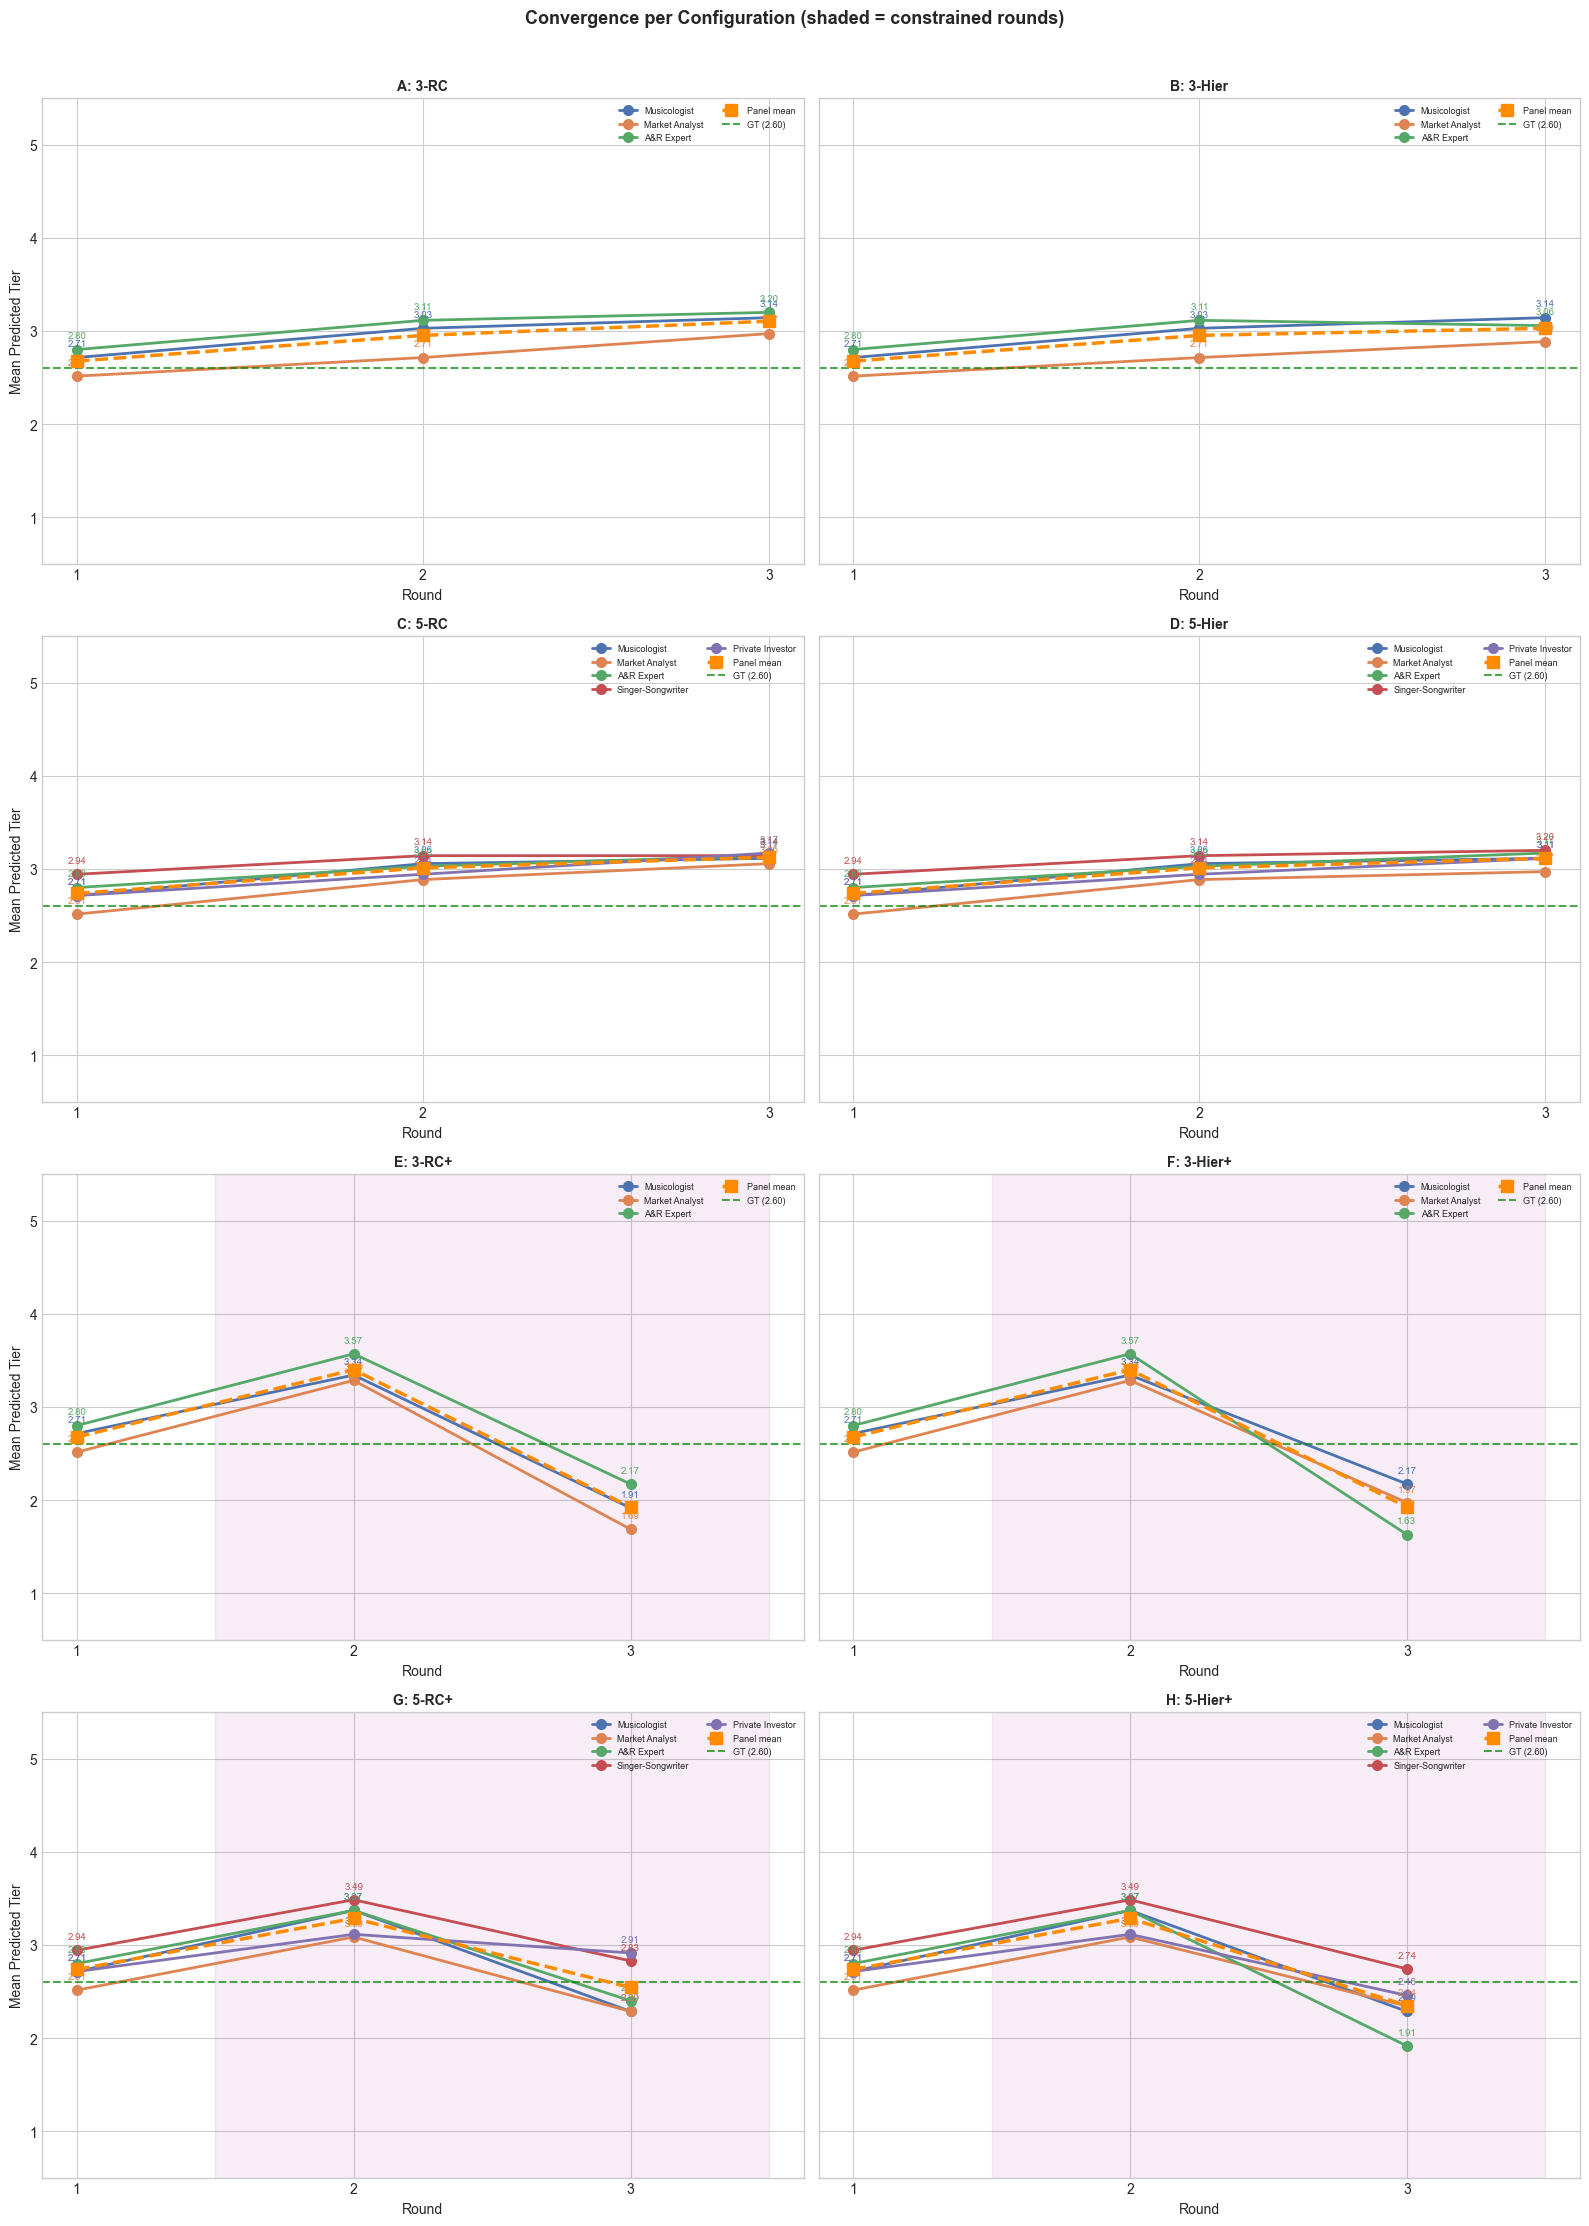

In [33]:
fig,axes=plt.subplots(4,2,figsize=(16,22),sharey=True)
pal_ag=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
gt_mean=np.mean([r['ground_truth'] for r in all_results])

for ax,(k,lbl,col,n_ag,agents,_) in zip(axes.flatten(),CONFIG_META):
    rlist=cfg_flat[k]
    for ag,c in zip(agents,pal_ag):
        means=[np.mean([get_tier(r,ri,ag) for r in rlist if len(r['conversation'])>ri])
               for ri in range(3)]
        ax.plot([1,2,3],means,'o-',color=c,lw=2,ms=7,label=AGENT_LABELS.get(ag,ag))
        for ri,m in enumerate(means):
            ax.text(ri+1,m+0.12,f'{m:.2f}',ha='center',fontsize=7,color=c)
    panel_means=[np.mean([np.mean([get_tier(r,ri,ag) for ag in agents])
                          for r in rlist if len(r['conversation'])>ri]) for ri in range(3)]
    ax.plot([1,2,3],panel_means,'s--',color='darkorange',lw=2.5,ms=9,
            label='Panel mean',zorder=5)
    ax.axhline(gt_mean,color='green',ls='--',lw=1.5,alpha=0.7,label=f'GT ({gt_mean:.2f})')
    ax.set_title(lbl,fontsize=10,fontweight='bold')
    ax.set_xticks([1,2,3]); ax.set_xlabel('Round'); ax.set_ylim(0.5,5.5); ax.set_yticks(range(1,6))
    if ax in axes[:,0]: ax.set_ylabel('Mean Predicted Tier')
    ax.legend(fontsize=6.5,loc='upper right',ncol=2)
    # shade R2/R3 constraint region for E-H
    if _: ax.axvspan(1.5,3.5,alpha=0.07,color='purple')

plt.suptitle('Convergence per Configuration (shaded = constrained rounds)',
             fontsize=13,fontweight='bold',y=1.01)
plt.tight_layout(); plt.show()

## 4 · Prediction Variance by Genre and Agent Role

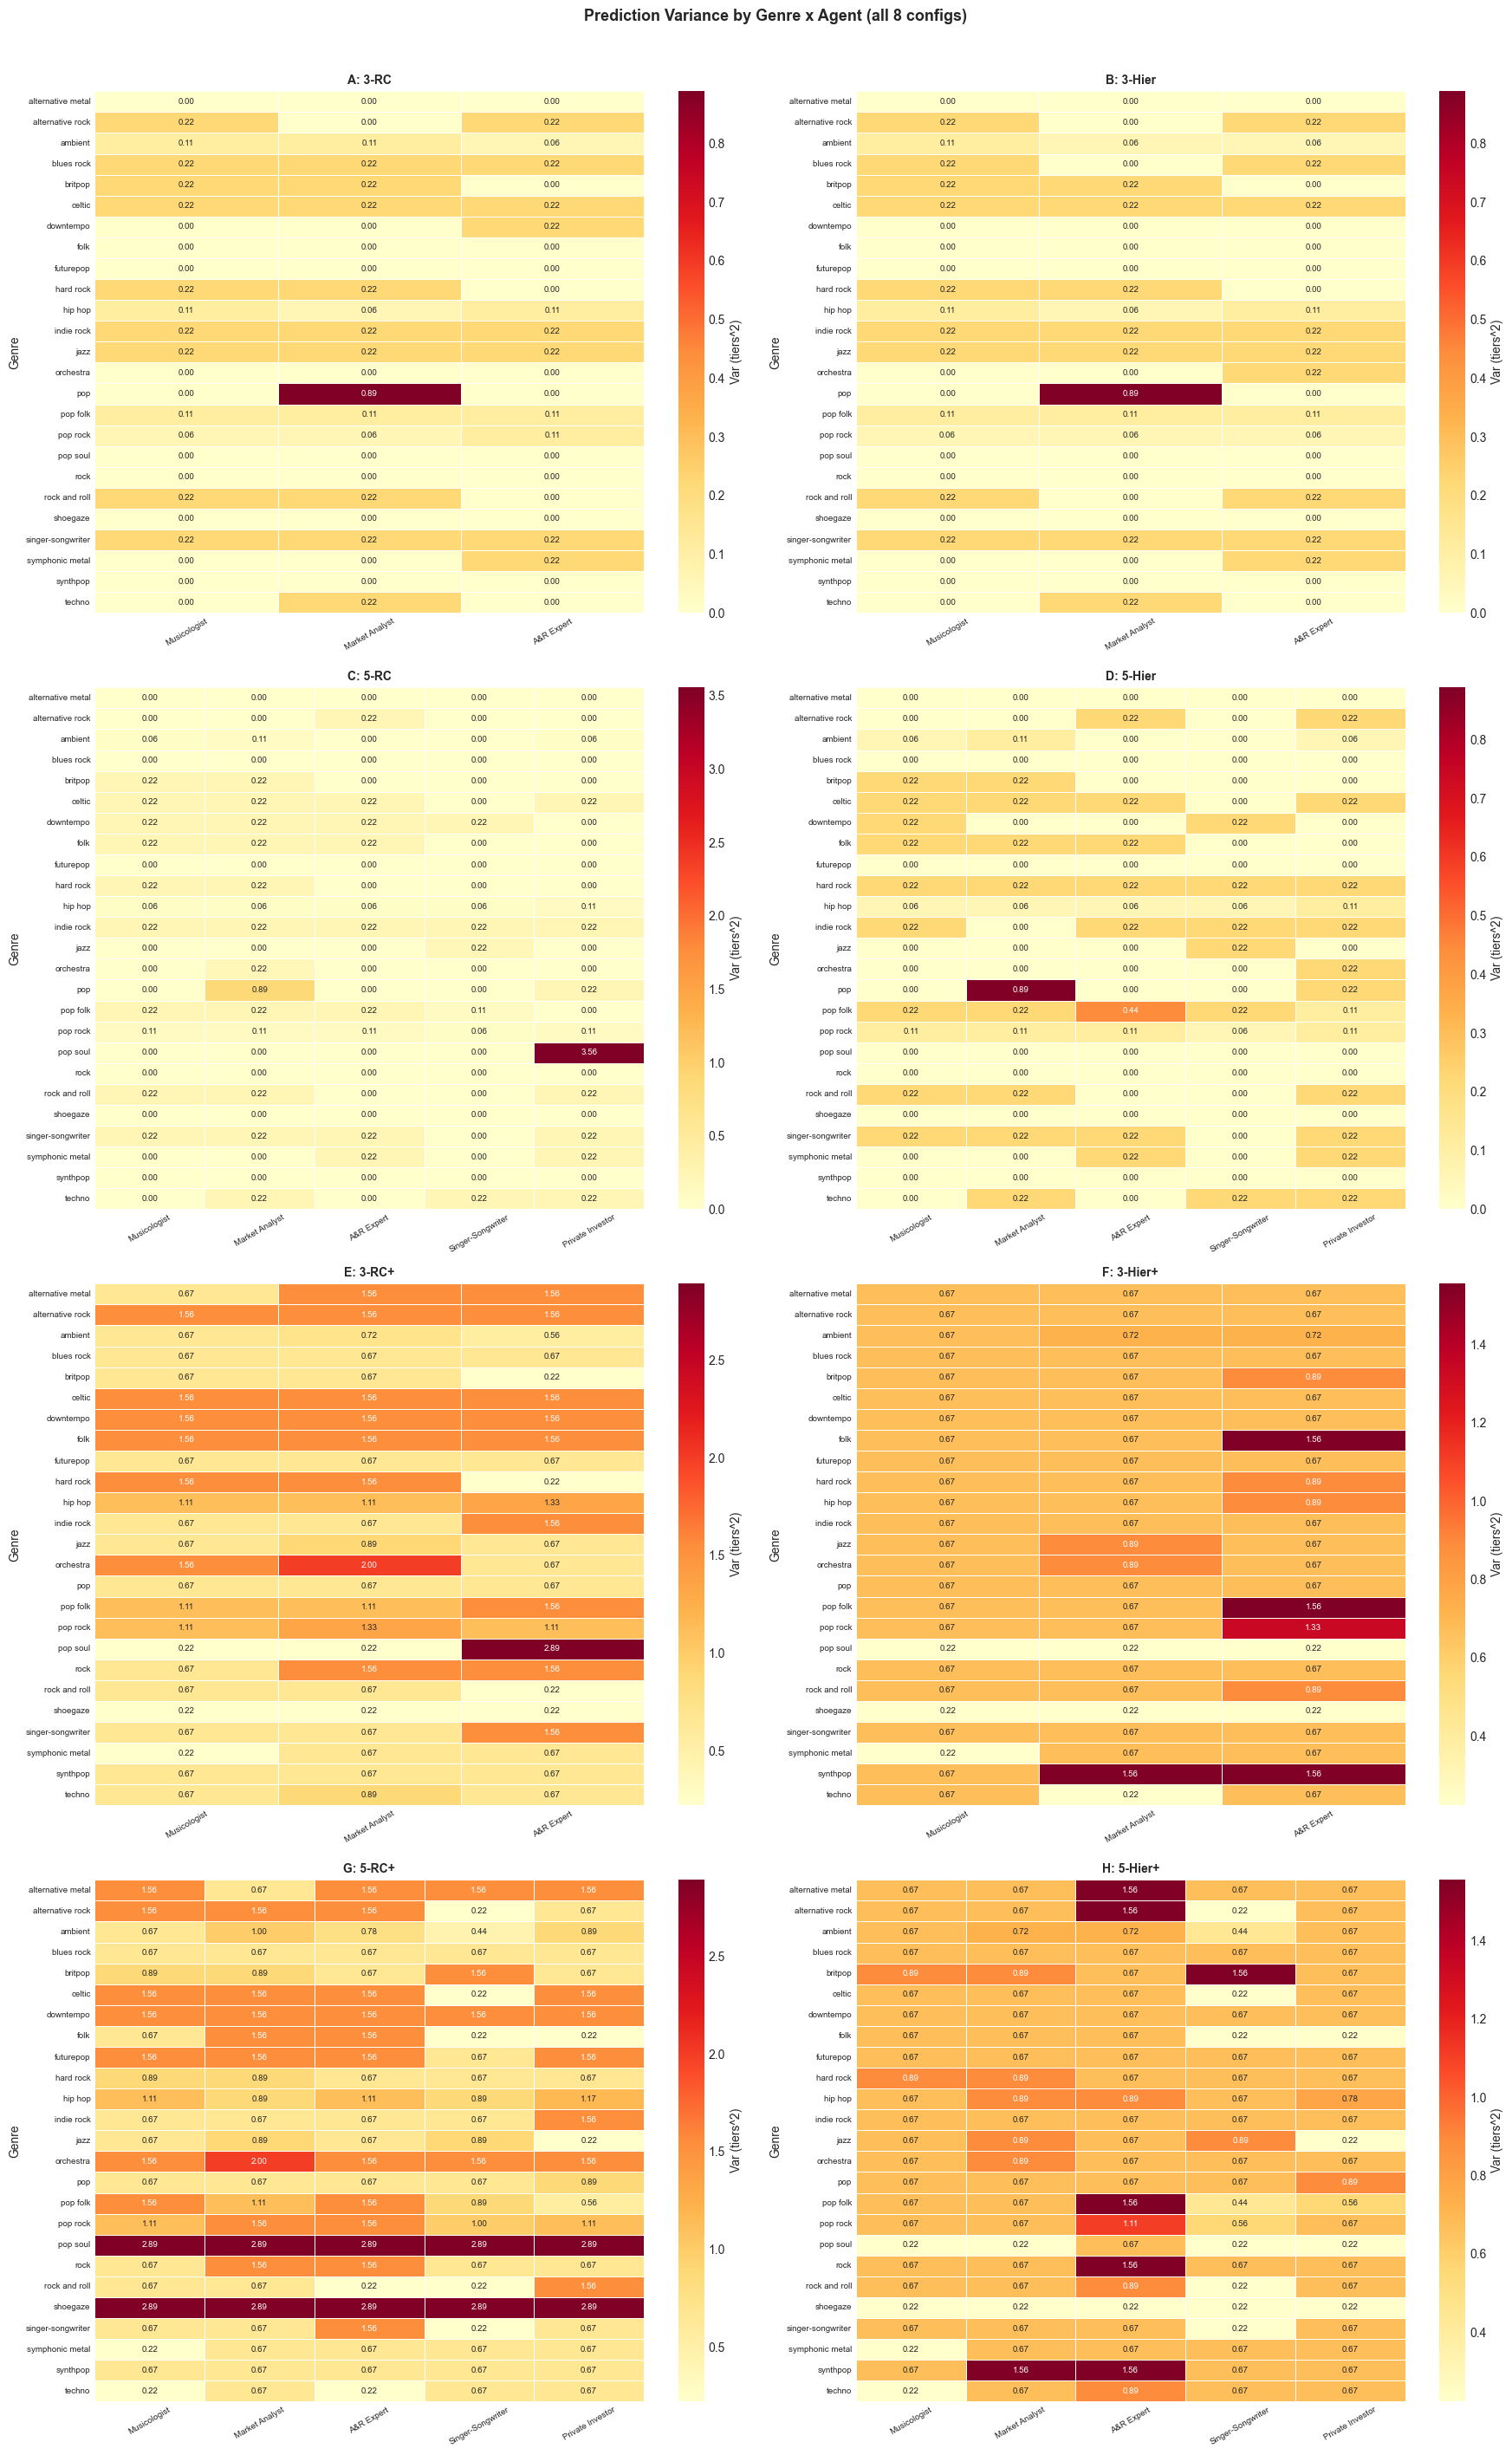

In [34]:
fig,axes=plt.subplots(4,2,figsize=(18,28))

for ax,(k,lbl,col,n_ag,agents,_) in zip(axes.flatten(),CONFIG_META):
    recs=[]
    for r in cfg_flat[k]:
        g=pgenre(r)
        for ag in agents:
            tiers=[get_tier(r,i,ag) for i in range(3) if len(r['conversation'])>i]
            recs.append({'genre':g,'agent':AGENT_LABELS.get(ag,ag),'var':float(np.var(tiers))})
    df=pd.DataFrame(recs)
    pivot=df.groupby(['genre','agent'])['var'].mean().unstack()
    pivot=pivot.reindex(columns=[AGENT_LABELS.get(a,a) for a in agents])
    sns.heatmap(pivot,ax=ax,annot=True,fmt='.2f',cmap='YlOrRd',
                linewidths=0.4,cbar_kws={'label':'Var (tiers^2)'},annot_kws={'size':7})
    ax.set_title(lbl,fontsize=10,fontweight='bold')
    ax.set_ylabel('Genre'); ax.set_xlabel('')
    ax.tick_params(axis='x',labelsize=7,rotation=30)
    ax.tick_params(axis='y',labelsize=7)

plt.suptitle('Prediction Variance by Genre x Agent (all 8 configs)',
             fontsize=13,fontweight='bold',y=1.01)
plt.tight_layout(); plt.show()

## 5 · Round 3 vs Round 1: Improvement Rate

A: 3-RC          R1 err=0.800  R3 err=0.943  improved=22.9%  cond_improved(R1-wrong)=33.3%  recovery(→exact)=25.0%  (n_wrong=24)
B: 3-Hier        R1 err=0.800  R3 err=0.971  improved=17.1%  cond_improved(R1-wrong)=25.0%  recovery(→exact)=20.8%  (n_wrong=24)
C: 5-RC          R1 err=0.811  R3 err=0.971  improved=25.7%  cond_improved(R1-wrong)=28.6%  recovery(→exact)=19.0%  (n_wrong=21)
D: 5-Hier        R1 err=0.811  R3 err=1.029  improved=22.9%  cond_improved(R1-wrong)=28.6%  recovery(→exact)=19.0%  (n_wrong=21)
E: 3-RC+         R1 err=0.800  R3 err=1.457  improved=17.1%  cond_improved(R1-wrong)=25.0%  recovery(→exact)=16.7%  (n_wrong=24)
F: 3-Hier+       R1 err=0.800  R3 err=1.429  improved=17.1%  cond_improved(R1-wrong)=25.0%  recovery(→exact)=16.7%  (n_wrong=24)
G: 5-RC+         R1 err=0.811  R3 err=1.486  improved=28.6%  cond_improved(R1-wrong)=42.9%  recovery(→exact)=19.0%  (n_wrong=21)
H: 5-Hier+       R1 err=0.811  R3 err=1.314  improved=28.6%  cond_improved(R1-wrong)=42.9%  recov

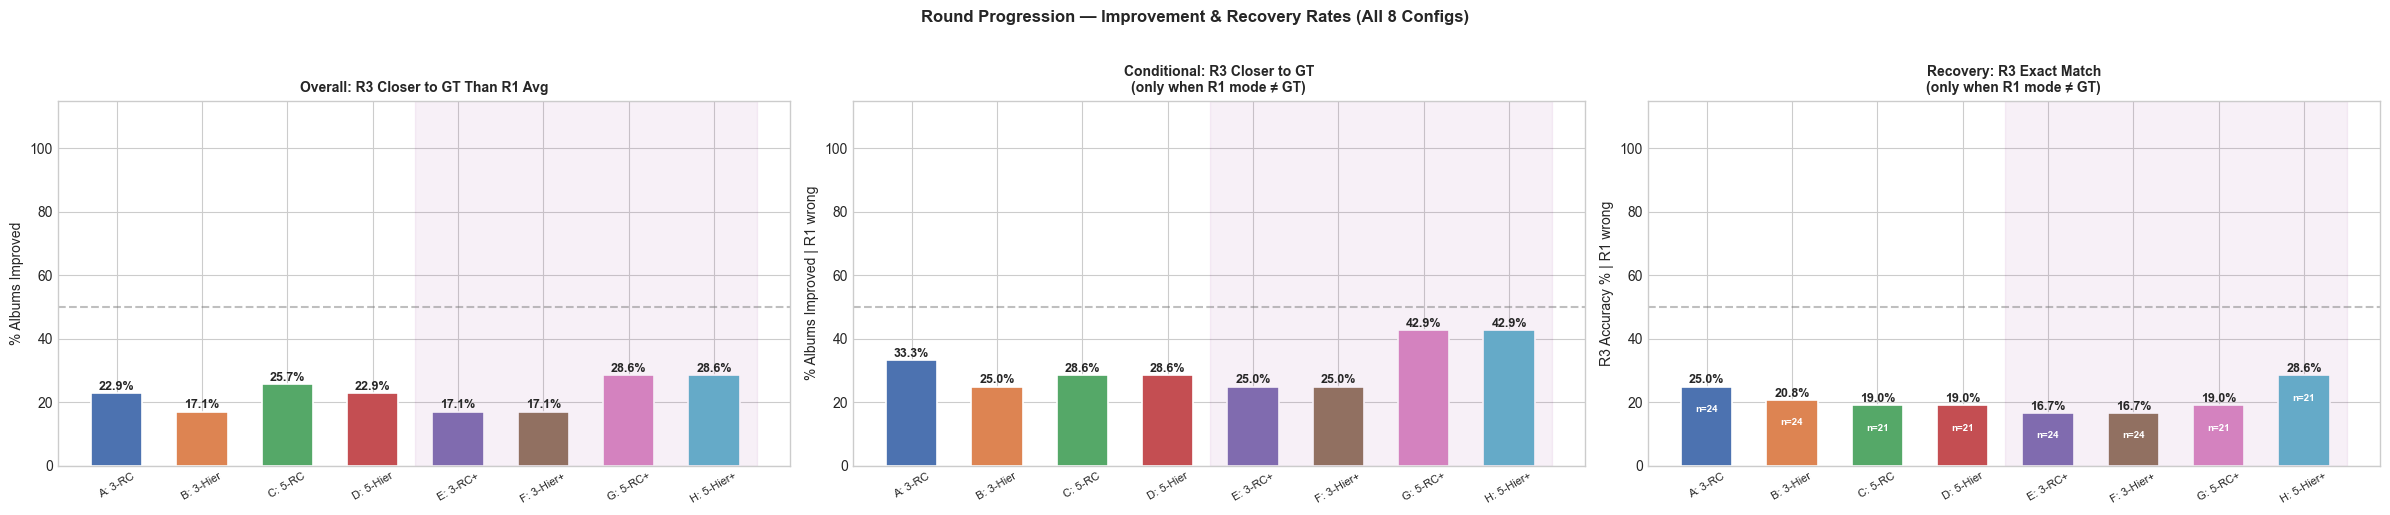


Config            Improved%  n_wrong   Cond.Imp%   Recovery%
------------------------------------------------------------
A: 3-RC               22.9%       24       33.3%       25.0%
B: 3-Hier             17.1%       24       25.0%       20.8%
C: 5-RC               25.7%       21       28.6%       19.0%
D: 5-Hier             22.9%       21       28.6%       19.0%
E: 3-RC+              17.1%       24       25.0%       16.7%
F: 3-Hier+            17.1%       24       25.0%       16.7%
G: 5-RC+              28.6%       21       42.9%       19.0%
H: 5-Hier+            28.6%       21       42.9%       28.6%


In [36]:
def round_improvement(rlist, agents):
    recs = []
    for r in rlist:
        gt = r['ground_truth']
        r1_tiers = [get_tier(r, 0, ag) for ag in agents]
        r1_avg   = np.mean(r1_tiers)
        r1_err   = abs(r1_avg - gt)
        r3_err   = abs(r['final_prediction'] - gt)
        from collections import Counter
        counts = Counter(r1_tiers); mx = max(counts.values())
        r1_mode = sorted(t for t, c in counts.items() if c == mx)[0]
        r1_mode_wrong = (r1_mode != gt)
        recs.append({
            'r1_err':        r1_err,
            'r3_err':        r3_err,
            'improved':      r3_err < r1_err,
            'r1_mode_wrong': r1_mode_wrong,
            'r3_correct':    r['final_prediction'] == gt,
        })
    improved_pct = sum(x['improved'] for x in recs) / len(recs) * 100
    wrong_start  = [x for x in recs if x['r1_mode_wrong']]
    # Recovery: R1 mode wrong → R3 exact match
    recovery_pct  = (sum(x['r3_correct']  for x in wrong_start) / len(wrong_start) * 100
                     if wrong_start else float('nan'))
    # Conditional improvement: R1 mode wrong → R3 closer to GT than R1
    cond_imp_pct  = (sum(x['improved']    for x in wrong_start) / len(wrong_start) * 100
                     if wrong_start else float('nan'))
    return recs, improved_pct, recovery_pct, cond_imp_pct, len(wrong_start)

pcts = {}; recov = {}; cond_imp = {}; n_wrong = {}
for k, lbl, col, n_ag, agents, _ in CONFIG_META:
    rec, imp, rec_pct, ci_pct, nw = round_improvement(cfg_flat[k], agents)
    pcts[k] = imp; recov[k] = rec_pct; cond_imp[k] = ci_pct; n_wrong[k] = nw
    r1m = np.mean([x['r1_err'] for x in rec])
    r3m = np.mean([x['r3_err'] for x in rec])
    print(f'{lbl:<16} R1 err={r1m:.3f}  R3 err={r3m:.3f}  '
          f'improved={imp:.1f}%  '
          f'cond_improved(R1-wrong)={ci_pct:.1f}%  '
          f'recovery(→exact)={rec_pct:.1f}%  (n_wrong={nw})')

# ── Plot ──────────────────────────────────────────────────────────────────────
_labels = [lbl for _, lbl, *_ in CONFIG_META]
_cols   = [col for _, _, col, *_ in CONFIG_META]
fig, axes = plt.subplots(1, 3, figsize=(24, 5))

def _bar(ax, vals, title, ylabel):
    bars = ax.bar(_labels, vals, color=_cols, width=0.6, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                    f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.axvspan(3.5, 7.5, alpha=0.06, color='purple')
    ax.set_ylim(0, 115); ax.set_ylabel(ylabel)
    ax.axhline(50, color='grey', ls='--', alpha=0.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8, rotation=30)

_bar(axes[0],
     [pcts[k] for k, *_ in CONFIG_META],
     'Overall: R3 Closer to GT Than R1 Avg',
     '% Albums Improved')

_bar(axes[1],
     [cond_imp[k] for k, *_ in CONFIG_META],
     'Conditional: R3 Closer to GT\n(only when R1 mode ≠ GT)',
     '% Albums Improved | R1 wrong')

_bar(axes[2],
     [recov[k] for k, *_ in CONFIG_META],
     'Recovery: R3 Exact Match\n(only when R1 mode ≠ GT)',
     'R3 Accuracy % | R1 wrong')

# annotate n_wrong on third chart
for bar, nw in zip(axes[2].patches, [n_wrong[k] for k, *_ in CONFIG_META]):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 max(bar.get_height()-8, 3),
                 f'n={nw}', ha='center', fontsize=7, color='white', fontweight='bold')

plt.suptitle('Round Progression — Improvement & Recovery Rates (All 8 Configs)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"Config":<16} {"Improved%":>10} {"n_wrong":>8} {"Cond.Imp%":>11} {"Recovery%":>11}')
print('-' * 60)
for k, lbl, *_ in CONFIG_META:
    print(f'{lbl:<16} {pcts[k]:>9.1f}% {n_wrong[k]:>8d} '
          f'{cond_imp[k]:>10.1f}% {recov[k]:>10.1f}%')


## 6 · Inter-Agent Analysis: R3 Disagreement vs Prediction Error

A: 3-RC          r=0.039 p=0.8225
B: 3-Hier        r=-0.060 p=0.7323
C: 5-RC          r=-0.181 p=0.2986
D: 5-Hier        r=0.313 p=0.0670
E: 3-RC+         r=0.023 p=0.8945
F: 3-Hier+       r=0.302 p=0.0779
G: 5-RC+         r=0.071 p=0.6856
H: 5-Hier+       r=0.060 p=0.7340


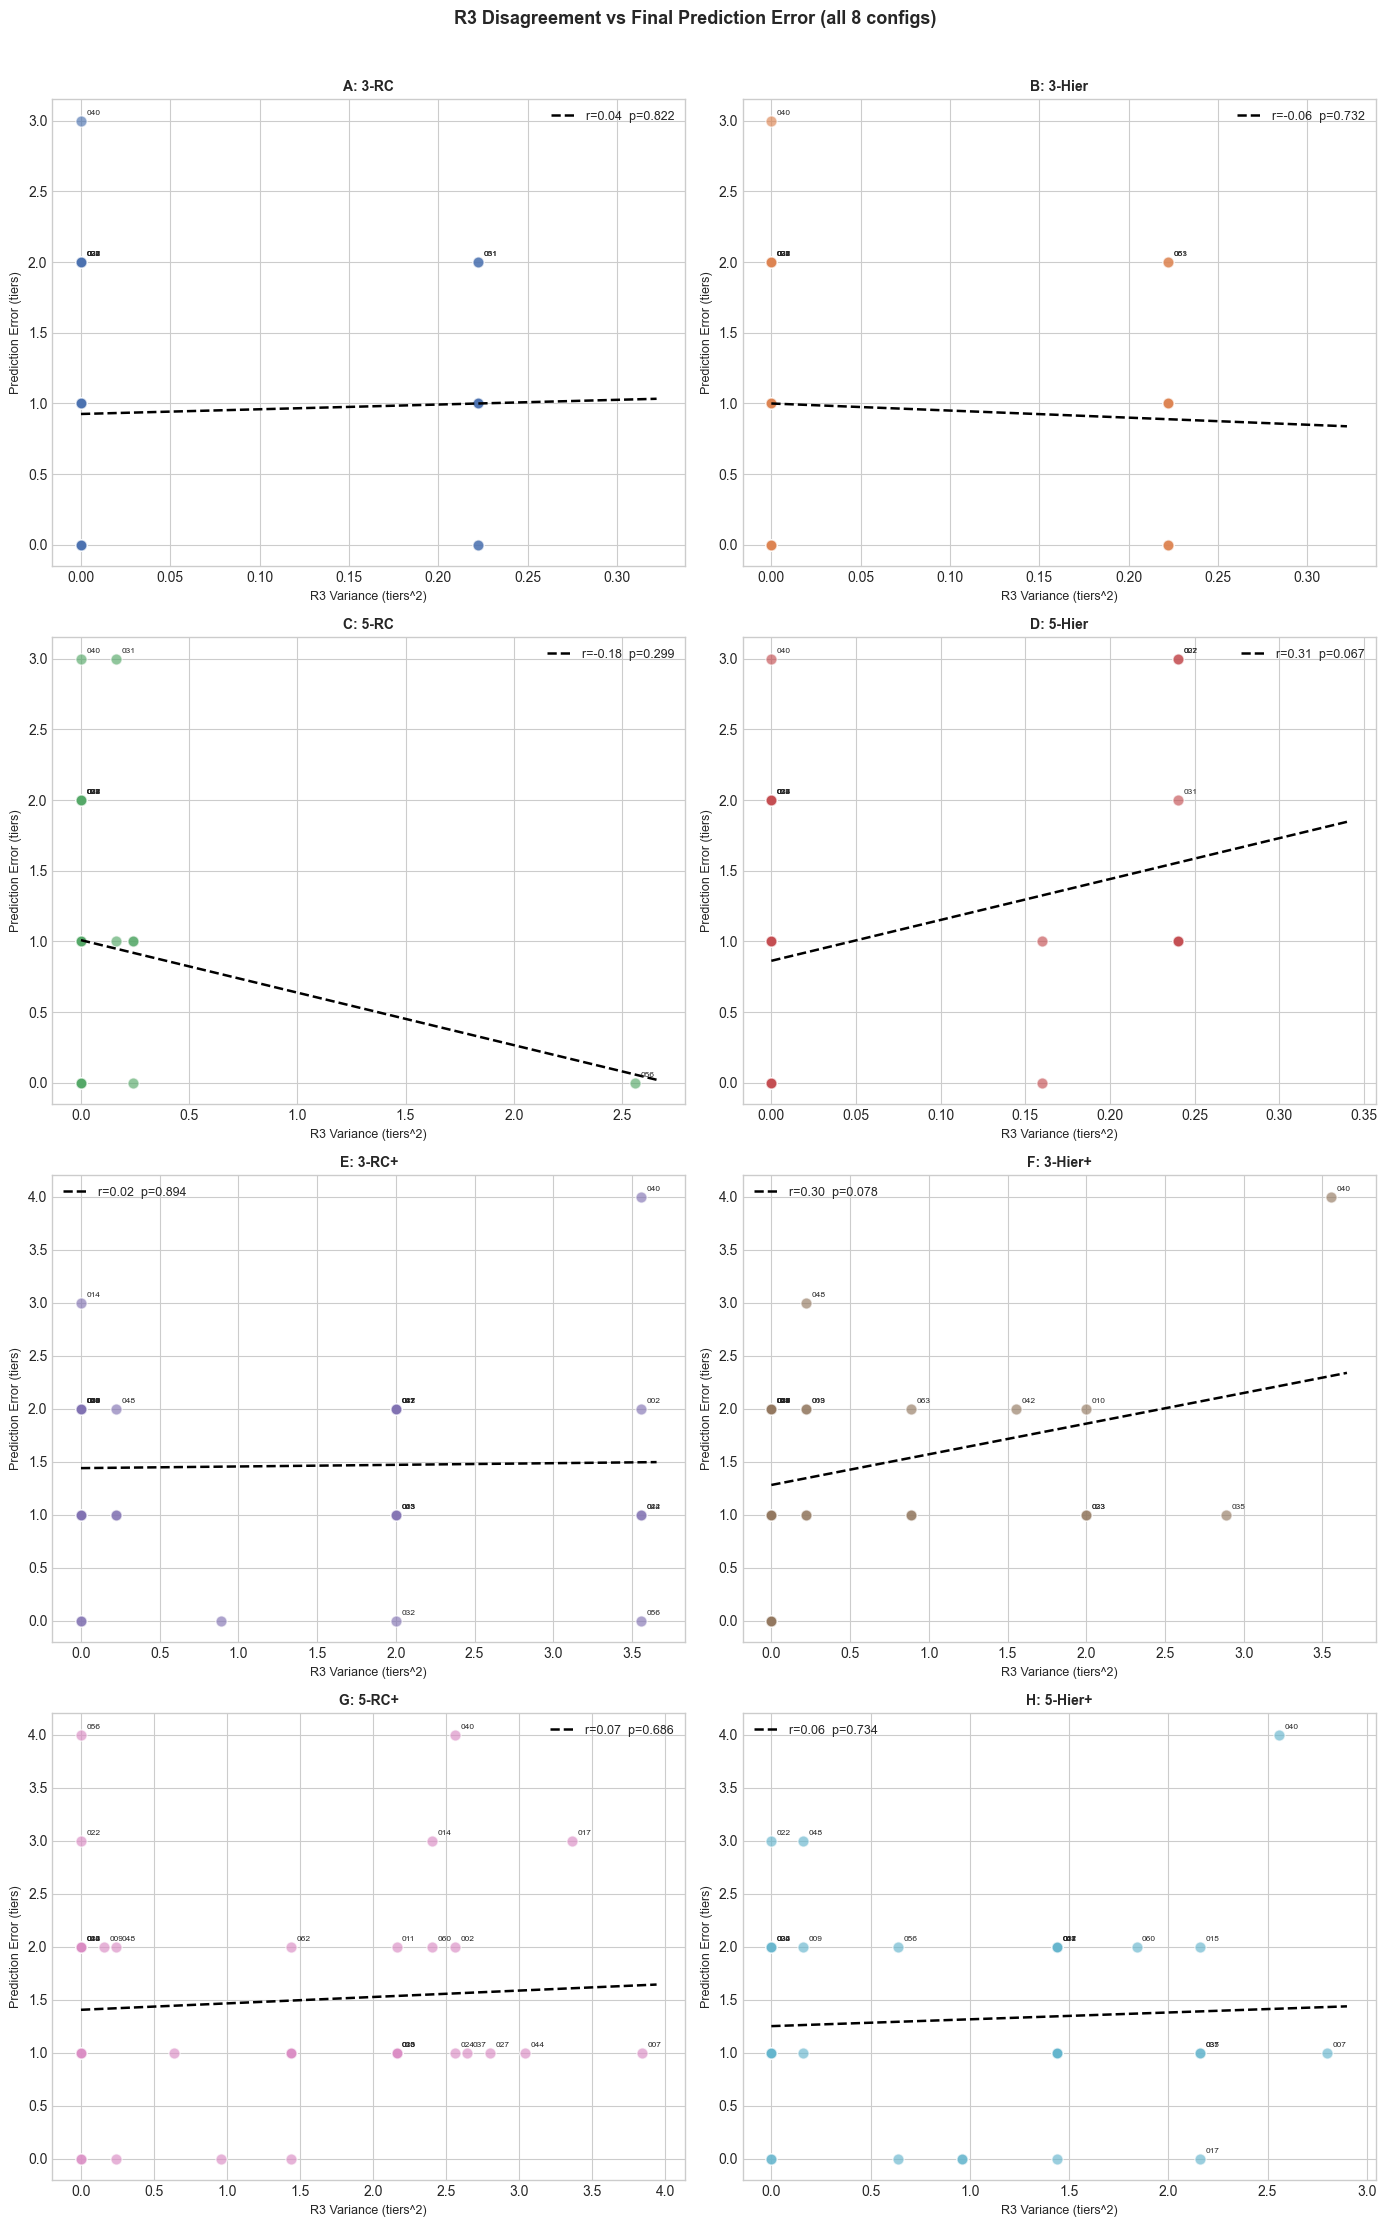

In [36]:
fig,axes=plt.subplots(4,2,figsize=(14,22))

for ax,(k,lbl,col,n_ag,agents,_) in zip(axes.flatten(),CONFIG_META):
    rlist=cfg_flat[k]
    vs,es,ids=[],[],[]
    for r in rlist:
        if len(r['conversation'])<3: continue
        r3_tiers=[get_tier(r,2,ag) for ag in agents]
        vs.append(float(np.var(r3_tiers)))
        es.append(abs(r['final_prediction']-r['ground_truth']))
        ids.append(r['album_id'])
    if len(vs)<3: ax.set_title(f'{lbl} (insufficient data)'); continue
    corr,pval=stats.pearsonr(vs,es)
    slope,intercept,*_=stats.linregress(vs,es)
    ax.scatter(vs,es,alpha=0.65,color=col,edgecolors='white',s=65)
    xl=np.linspace(0,max(vs)+0.1,100)
    ax.plot(xl,slope*xl+intercept,'--',color='black',lw=1.8,
            label=f'r={corr:.2f}  p={pval:.3f}')
    for aid,v,e in zip(ids,vs,es):
        if e>=2 or v>=2: ax.annotate(aid,(v,e),xytext=(4,4),
                                     textcoords='offset points',fontsize=6)
    ax.set_xlabel('R3 Variance (tiers^2)',fontsize=9)
    ax.set_ylabel('Prediction Error (tiers)',fontsize=9)
    ax.set_title(lbl,fontsize=10,fontweight='bold')
    ax.legend(fontsize=9)
    sig='*' if pval<0.05 else ''
    print(f'{lbl:<16} r={corr:.3f} p={pval:.4f}{sig}')

plt.suptitle('R3 Disagreement vs Final Prediction Error (all 8 configs)',
             fontsize=13,fontweight='bold',y=1.01)
plt.tight_layout(); plt.show()

## 7 · Prediction Error Patterns — Genre and Audio Features

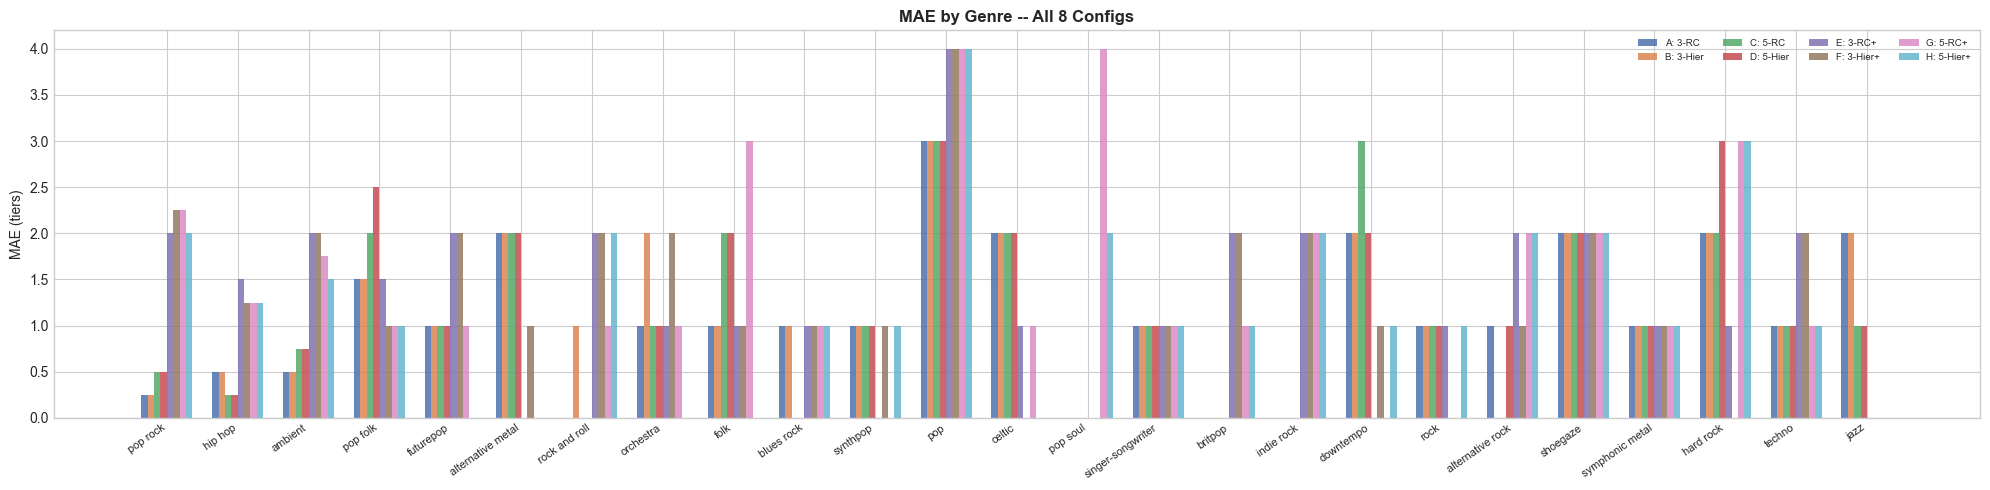

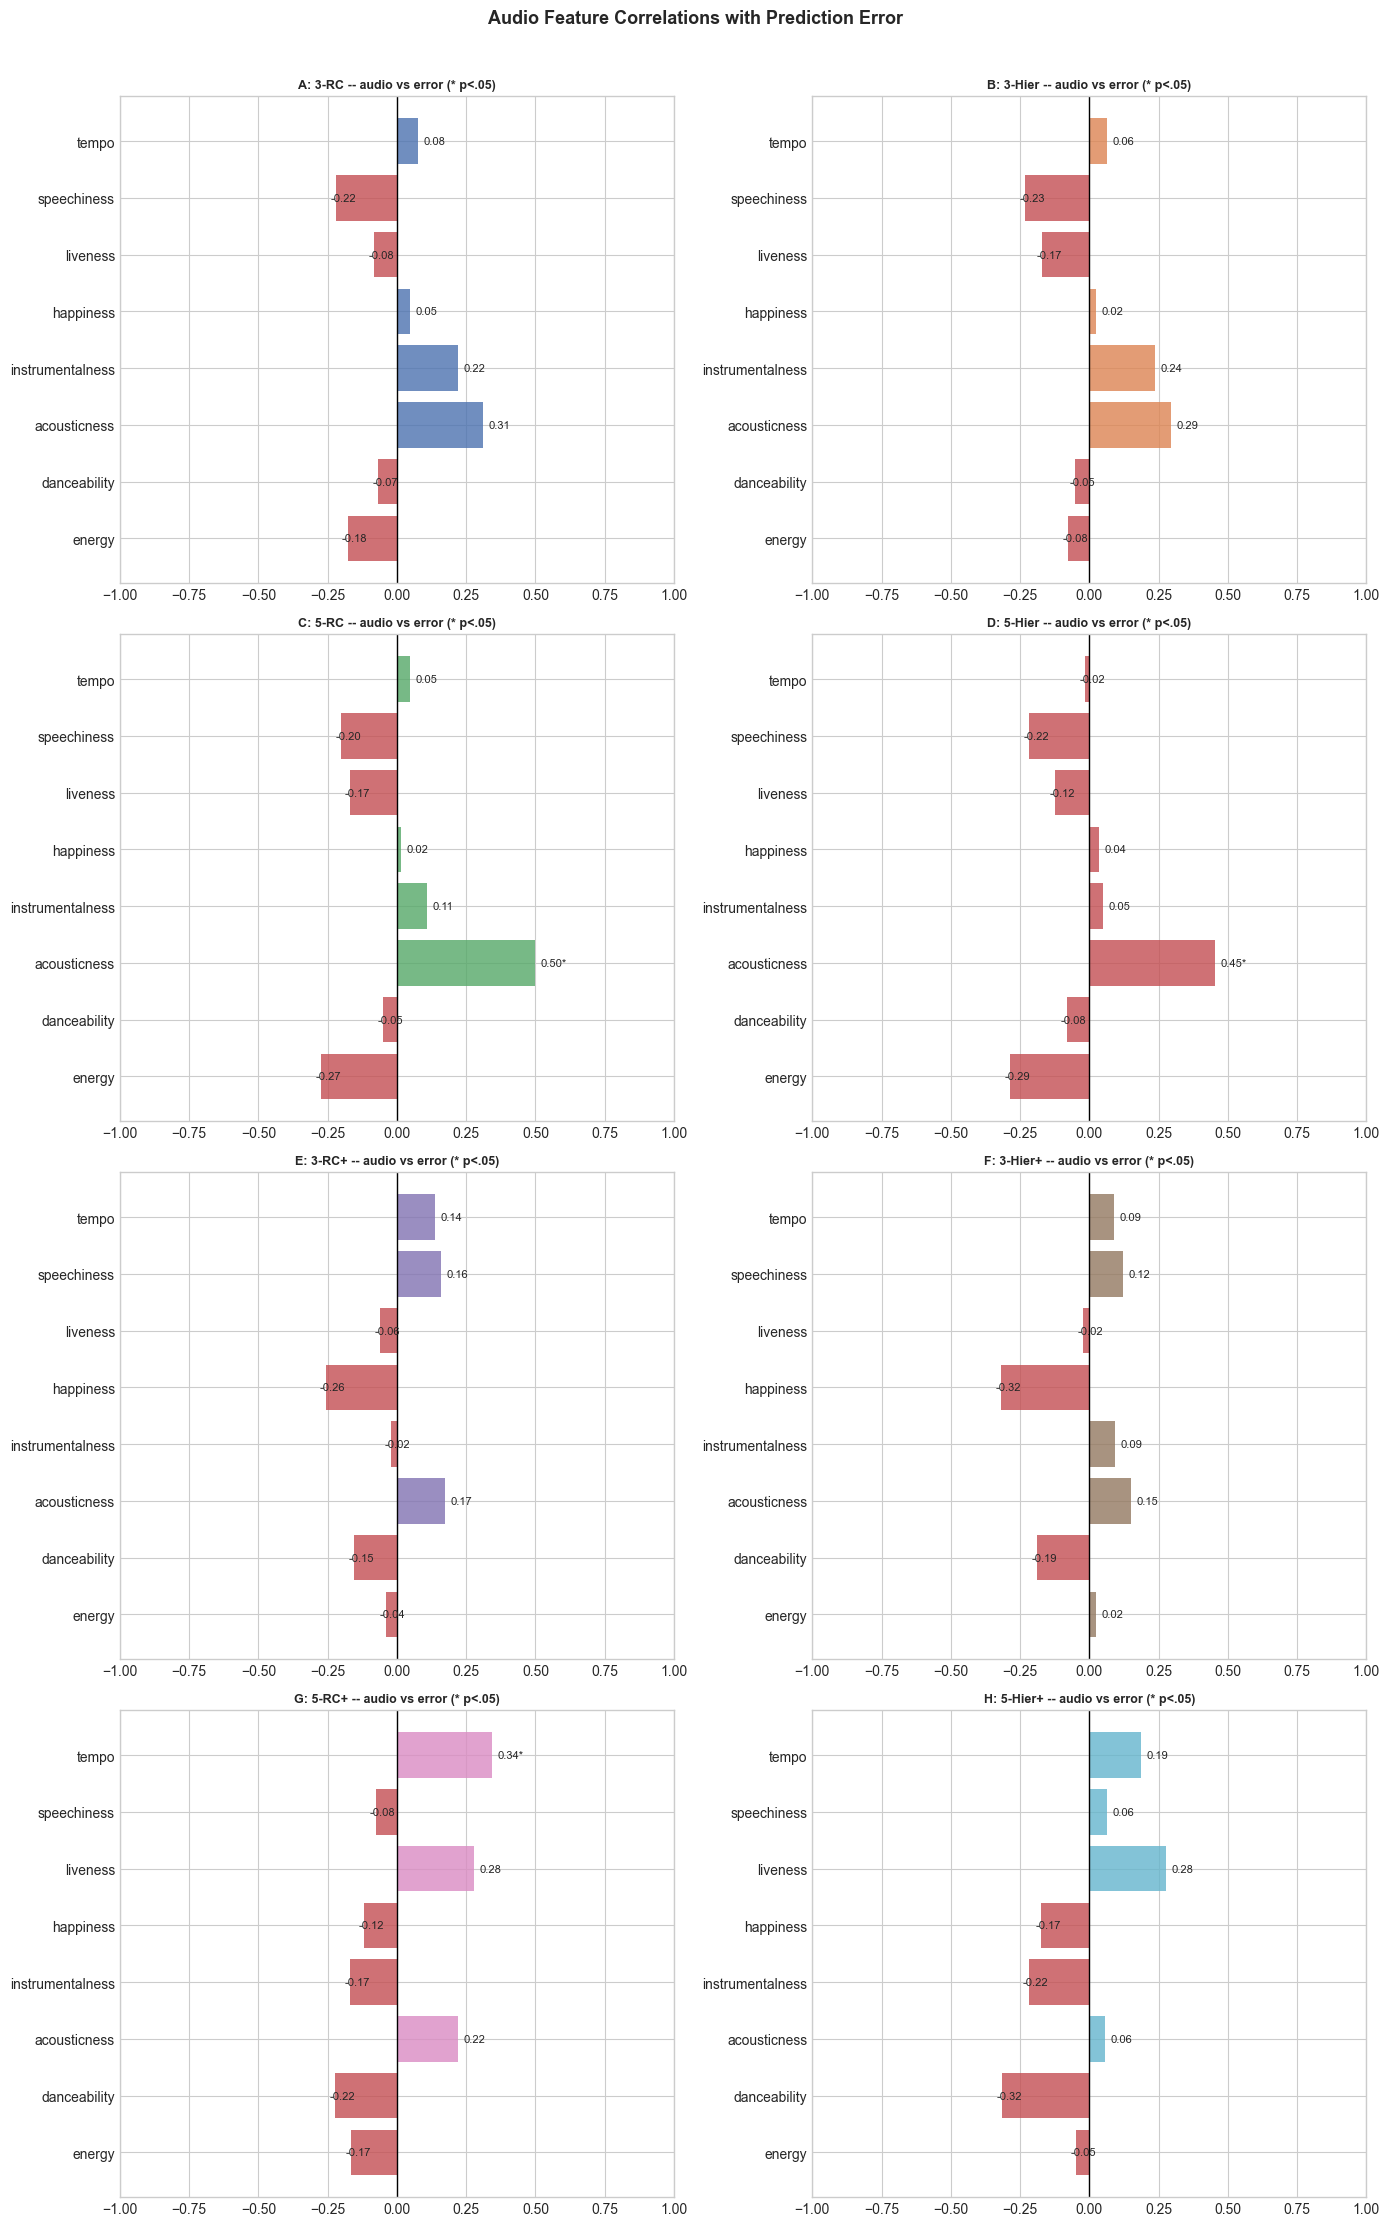

In [37]:
# 7a MAE by genre
g_mae={k:{g:np.mean([abs(r['final_prediction']-r['ground_truth'])
                      for r in cfg_flat[k] if pgenre(r)==g])
          for g in all_genres} for k in KEYS}
x=np.arange(len(all_genres)); offs=np.linspace(-3.5*w,3.5*w,8)
fig,ax=plt.subplots(figsize=(20,5))
for (k,lbl,col,*_),off in zip(CONFIG_META,offs):
    ax.bar(x+off,[g_mae[k].get(g,0) for g in all_genres],w,label=lbl,color=col,alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(all_genres,rotation=35,ha='right',fontsize=8)
ax.set_ylabel('MAE (tiers)'); ax.axvspan(3.5,7.5,alpha=0.0)  # placeholder
ax.set_title('MAE by Genre -- All 8 Configs',fontsize=12,fontweight='bold')
ax.legend(fontsize=7,ncol=4); plt.tight_layout(); plt.show()

# 7b Audio feature correlations -- 4x2 grid
audio_keys=['energy','danceability','acousticness','instrumentalness',
            'happiness','liveness','speechiness','tempo']

def audio_corr(rlist):
    rows=[{'error':abs(r['final_prediction']-r['ground_truth']),
           **{k:(r.get('audio_means') or {}).get(k) for k in audio_keys}} for r in rlist]
    df=pd.DataFrame(rows).dropna()
    return {k:stats.pearsonr(df[k],df['error']) for k in audio_keys}

ac={k:audio_corr(cfg_flat[k]) for k in KEYS}
fig,axes=plt.subplots(4,2,figsize=(14,22))
for ax,(k,lbl,col,*_) in zip(axes.flatten(),CONFIG_META):
    rs=[ac[k][feat][0] for feat in audio_keys]
    ps=[ac[k][feat][1] for feat in audio_keys]
    bcs=['#C44E52' if r<0 else col for r in rs]
    ax.barh(audio_keys,rs,color=bcs,alpha=0.8)
    for feat,rv,pv in zip(audio_keys,rs,ps):
        mk='*' if pv<0.05 else ''
        ax.text(rv+(0.02 if rv>=0 else -0.02),audio_keys.index(feat),
                f'{rv:.2f}{mk}',va='center',fontsize=8)
    ax.axvline(0,color='black',lw=1); ax.set_xlim(-1,1)
    ax.set_title(f'{lbl} -- audio vs error (* p<.05)',fontsize=9,fontweight='bold')
plt.suptitle('Audio Feature Correlations with Prediction Error',
             fontsize=13,fontweight='bold',y=1.01)
plt.tight_layout(); plt.show()

## 8 · Albums with Largest Prediction Gap

A: 3-RC: [040] The Miracles - Hi We're The Miracles GT=1 Pred=4 Gap=3 (over)
B: 3-Hier: [040] The Miracles - Hi We're The Miracles GT=1 Pred=4 Gap=3 (over)
C: 5-RC: [031] Chris Botti - When I Fall In Love GT=2 Pred=5 Gap=3 (over)
D: 5-Hier: [022] The Tragically Hip - Up to Here GT=2 Pred=5 Gap=3 (over)
E: 3-RC+: [040] The Miracles - Hi We're The Miracles GT=1 Pred=5 Gap=4 (over)
F: 3-Hier+: [040] The Miracles - Hi We're The Miracles GT=1 Pred=5 Gap=4 (over)
G: 5-RC+: [040] The Miracles - Hi We're The Miracles GT=1 Pred=5 Gap=4 (over)
H: 5-Hier+: [040] The Miracles - Hi We're The Miracles GT=1 Pred=5 Gap=4 (over)


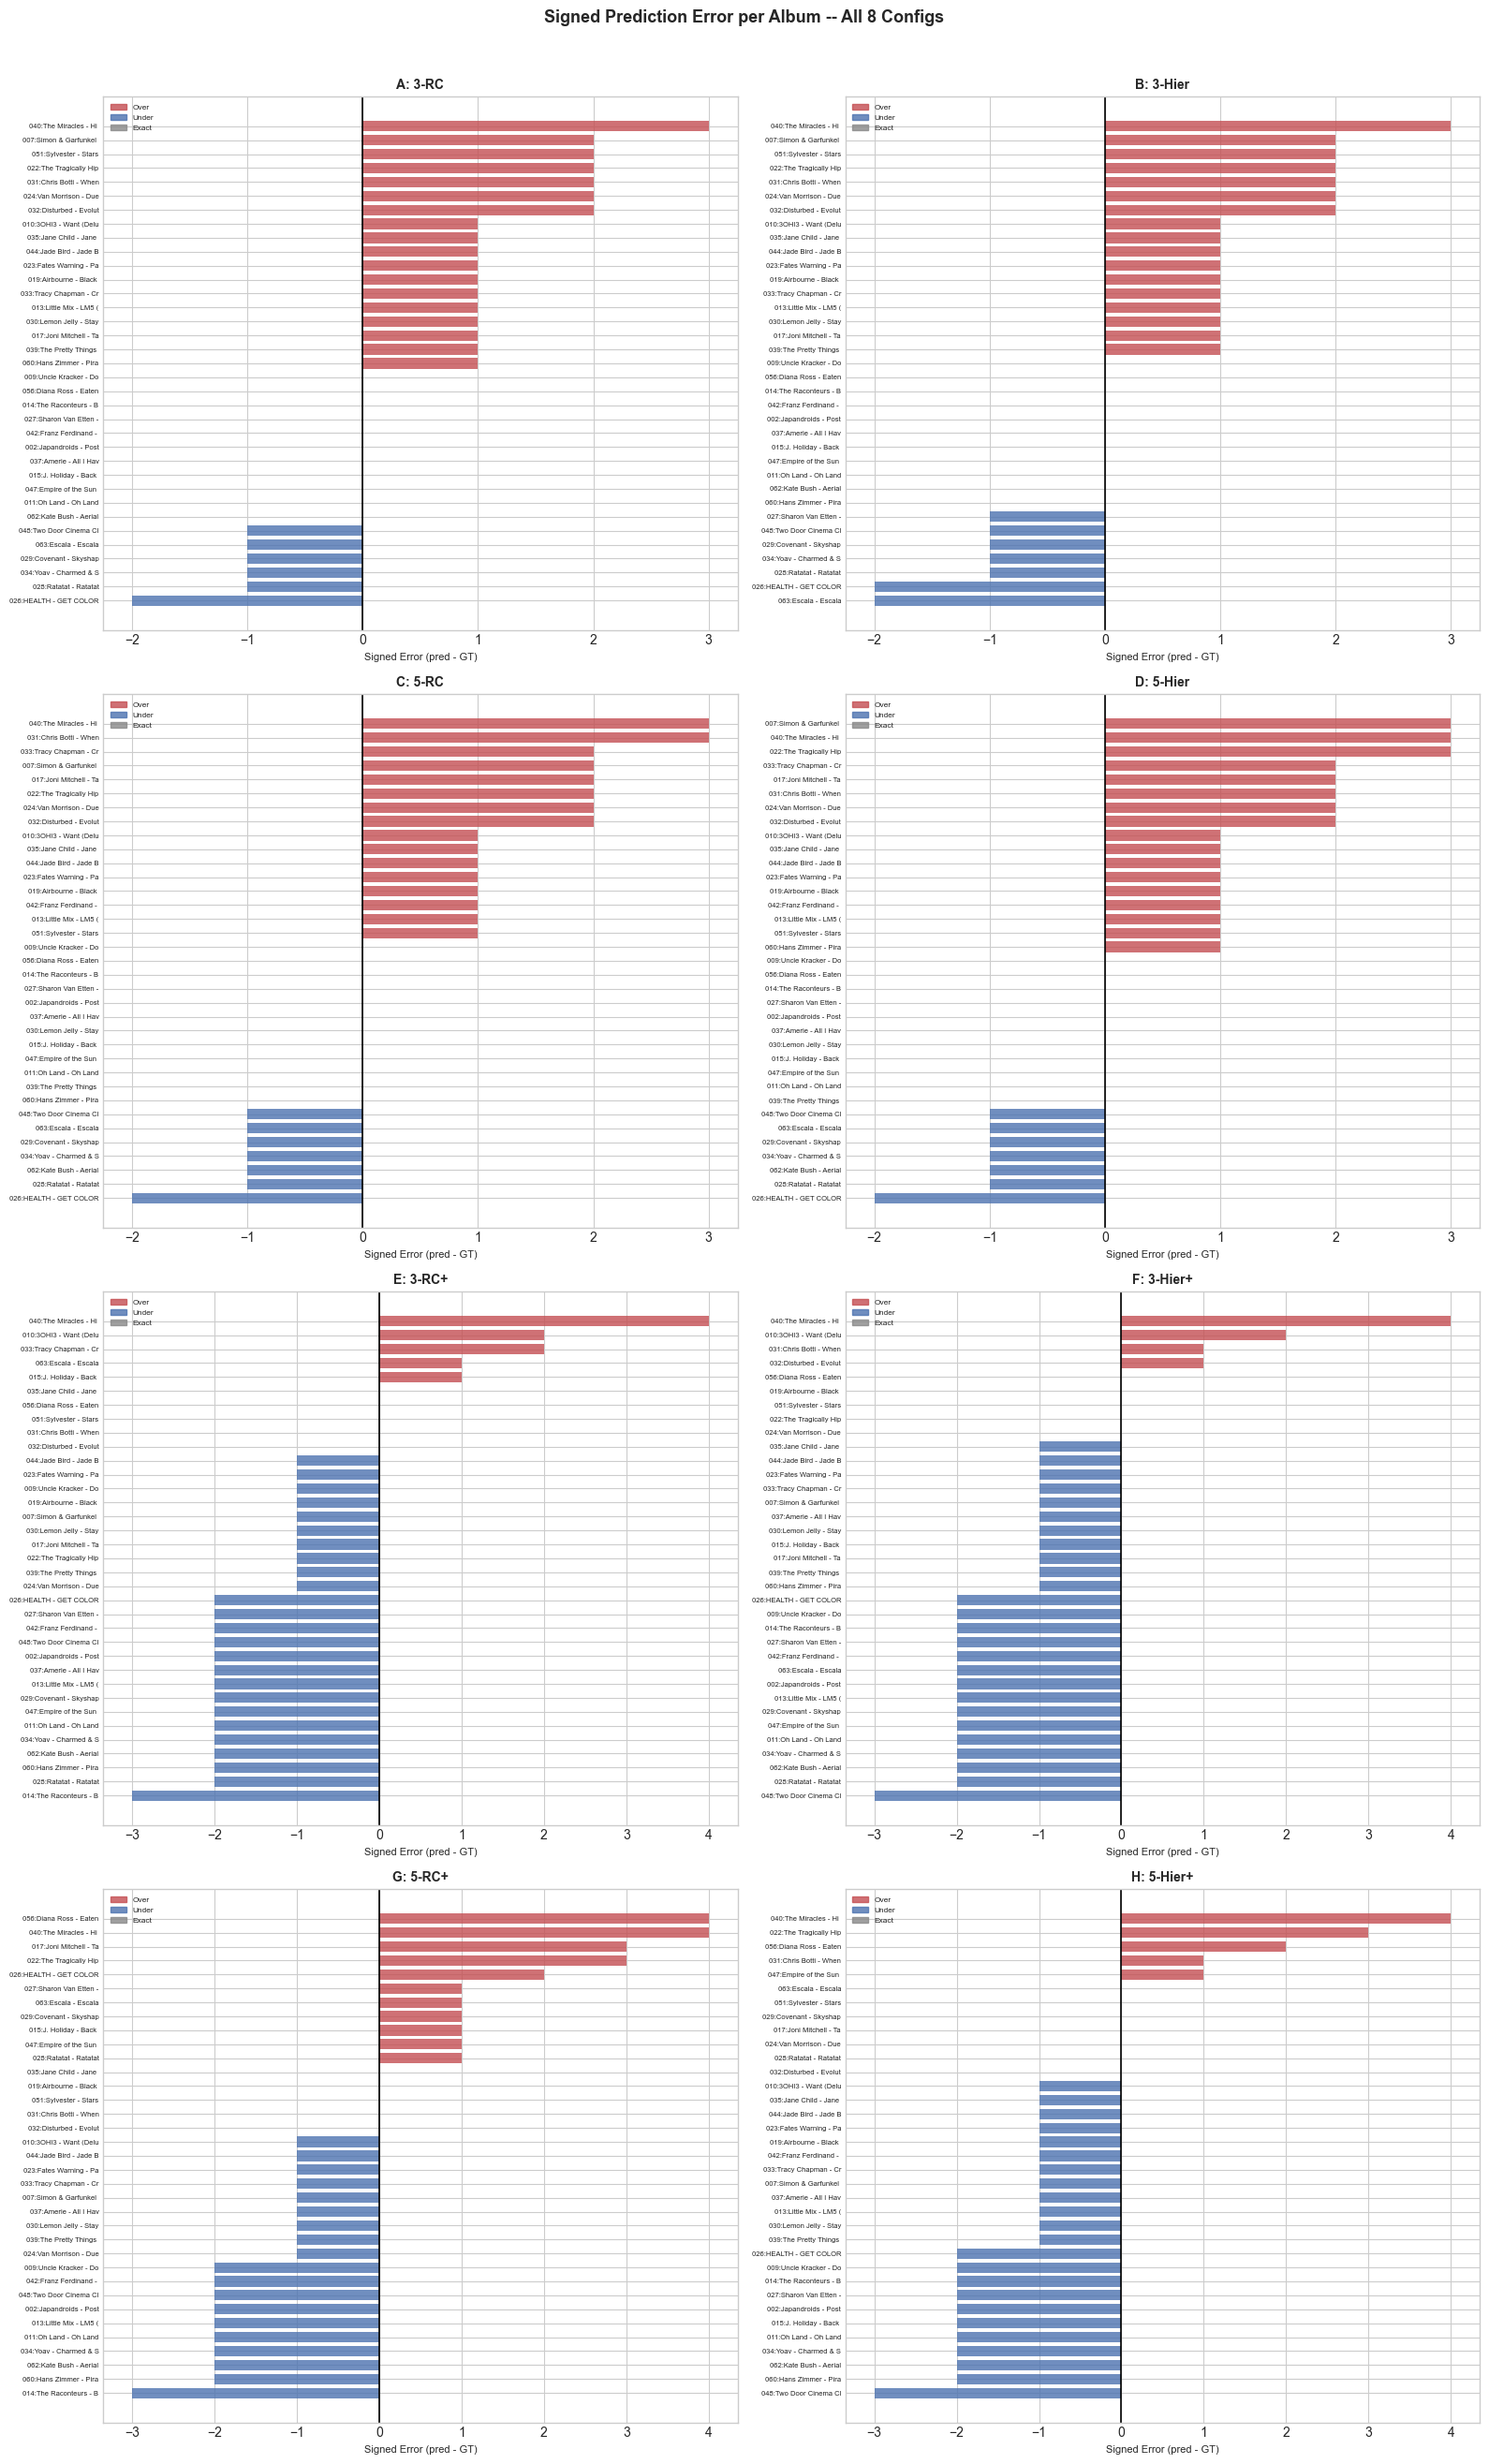

In [38]:
for k,lbl,col,n_ag,agents,_ in CONFIG_META:
    rlist=sorted(cfg_flat[k],key=lambda r:abs(r['final_prediction']-r['ground_truth']),reverse=True)
    worst=rlist[0]
    gap=abs(worst['final_prediction']-worst['ground_truth'])
    direction='over' if worst['final_prediction']>worst['ground_truth'] else 'under'
    print(f'{lbl}: [{worst["album_id"]}] {worst["album_label"][:45]} '
          f'GT={worst["ground_truth"]} Pred={worst["final_prediction"]} '
          f'Gap={gap} ({direction})')

# signed-error waterfall 4x2
fig,axes=plt.subplots(4,2,figsize=(16,26))
for ax,(k,lbl,col,*_) in zip(axes.flatten(),CONFIG_META):
    rlist=sorted(cfg_flat[k],key=lambda r:r['final_prediction']-r['ground_truth'])
    signed=[r['final_prediction']-r['ground_truth'] for r in rlist]
    lbls=[f'{r["album_id"]}:{r["album_label"][:18]}' for r in rlist]
    bcs=['#C44E52' if e>0 else ('#4C72B0' if e<0 else '#888') for e in signed]
    ax.barh(range(len(rlist)),signed,color=bcs,alpha=0.8,height=0.75)
    ax.set_yticks(range(len(rlist))); ax.set_yticklabels(lbls,fontsize=5.5)
    ax.axvline(0,color='black',lw=1.2)
    ax.set_xlabel('Signed Error (pred - GT)',fontsize=8)
    ax.set_title(lbl,fontsize=10,fontweight='bold')
    ax.legend(handles=[
        mpatches.Patch(color='#C44E52',alpha=0.8,label='Over'),
        mpatches.Patch(color='#4C72B0',alpha=0.8,label='Under'),
        mpatches.Patch(color='#888',   alpha=0.8,label='Exact')],fontsize=6)
plt.suptitle('Signed Prediction Error per Album -- All 8 Configs',
             fontsize=13,fontweight='bold',y=1.01)
plt.tight_layout(); plt.show()

## 9 · Ranked-Choice vs Hierarchical

Comparing paired configs (same agent count + same decision method) to isolate the effect of the
decision mechanism.

Pair                      RC Acc  Hier Acc    RC MAE  Hier MAE Winner
-----------------------------------------------------------------
Standard 3-agent           31.4%     31.4%      0.94      0.97  Tie
Standard 5-agent           34.3%     31.4%      0.97      1.03  RC (C)
Dissentient 3-agent        14.3%     14.3%      1.46      1.43  Tie
Dissentient 5-agent        14.3%     20.0%      1.49      1.31  Hier (H)


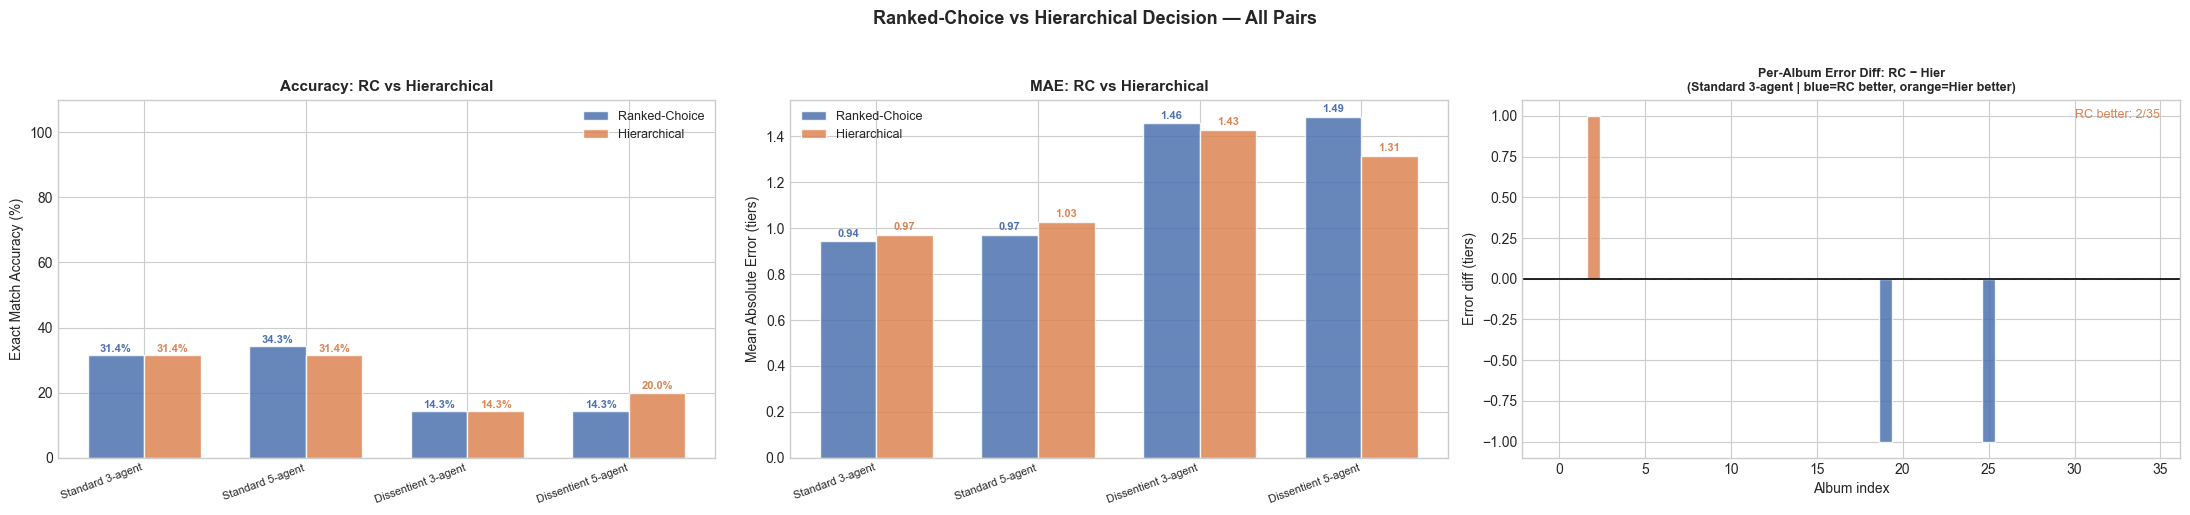

In [37]:
## 10 · Ranked-Choice vs Hierarchical: Head-to-Head

rc_hier_pairs = [
    ('config_a', 'config_b', 'Standard 3-agent',    'RC (A)', 'Hier (B)'),
    ('config_c', 'config_d', 'Standard 5-agent',    'RC (C)', 'Hier (D)'),
    ('config_e', 'config_f', 'Dissentient 3-agent', 'RC (E)', 'Hier (F)'),
    ('config_g', 'config_h', 'Dissentient 5-agent', 'RC (G)', 'Hier (H)'),
]

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Pair':<22} {'RC Acc':>9} {'Hier Acc':>9} {'RC MAE':>9} {'Hier MAE':>9} {'Winner'}")
print('-' * 65)
for ka, kb, lbl, la, lb in rc_hier_pairs:
    ra = cfg_mets[ka]['accuracy']; ha = cfg_mets[kb]['accuracy']
    rm = cfg_mets[ka]['mae'];      hm = cfg_mets[kb]['mae']
    winner = la if ra > ha else (lb if ha > ra else 'Tie')
    print(f'{lbl:<22} {ra:>8.1f}% {ha:>8.1f}% {rm:>9.2f} {hm:>9.2f}  {winner}')

# ── Figure: 3 subplots (Accuracy, MAE, per-album error diff) ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

pair_labels  = [lbl for _, _, lbl, _, _ in rc_hier_pairs]
rc_accs      = [cfg_mets[ka]['accuracy'] for ka, *_ in rc_hier_pairs]
hier_accs    = [cfg_mets[kb]['accuracy'] for _, kb, *_ in rc_hier_pairs]
rc_maes      = [cfg_mets[ka]['mae']      for ka, *_ in rc_hier_pairs]
hier_maes    = [cfg_mets[kb]['mae']      for _, kb, *_ in rc_hier_pairs]

x = np.arange(len(rc_hier_pairs))
w = 0.35

# Accuracy comparison
bars1 = axes[0].bar(x - w/2, rc_accs,   w, label='Ranked-Choice', color='#4C72B0', alpha=0.85, edgecolor='white')
bars2 = axes[0].bar(x + w/2, hier_accs, w, label='Hierarchical',  color='#DD8452', alpha=0.85, edgecolor='white')
for bar, v in zip(bars1, rc_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold', color='#4C72B0')
for bar, v in zip(bars2, hier_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold', color='#DD8452')
axes[0].set_xticks(x)
axes[0].set_xticklabels(pair_labels, rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('Exact Match Accuracy (%)')
axes[0].set_ylim(0, 110)
axes[0].set_title('Accuracy: RC vs Hierarchical', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# MAE comparison
bars3 = axes[1].bar(x - w/2, rc_maes,   w, label='Ranked-Choice', color='#4C72B0', alpha=0.85, edgecolor='white')
bars4 = axes[1].bar(x + w/2, hier_maes, w, label='Hierarchical',  color='#DD8452', alpha=0.85, edgecolor='white')
for bar, v in zip(bars3, rc_maes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{v:.2f}', ha='center', fontsize=8, fontweight='bold', color='#4C72B0')
for bar, v in zip(bars4, hier_maes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{v:.2f}', ha='center', fontsize=8, fontweight='bold', color='#DD8452')
axes[1].set_xticks(x)
axes[1].set_xticklabels(pair_labels, rotation=20, ha='right', fontsize=8)
axes[1].set_ylabel('Mean Absolute Error (tiers)')
axes[1].set_title('MAE: RC vs Hierarchical', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

# Per-album error difference (RC - Hier, negative = RC better)
# Use the first pair (Standard 3-agent) as representative
ka0, kb0 = 'config_a', 'config_b'
diffs = [
    abs(cfg_flat[ka0][i]['final_prediction'] - cfg_flat[ka0][i]['ground_truth']) -
    abs(cfg_flat[kb0][i]['final_prediction'] - cfg_flat[kb0][i]['ground_truth'])
    for i in range(len(all_results))
]
cols_d = ['#4C72B0' if d < 0 else ('#DD8452' if d > 0 else '#888') for d in diffs]
axes[2].bar(range(len(diffs)), diffs, color=cols_d, alpha=0.85, edgecolor='white')
axes[2].axhline(0, color='black', lw=1.2)
axes[2].set_title('Per-Album Error Diff: RC − Hier\n(Standard 3-agent | blue=RC better, orange=Hier better)',
                  fontsize=9, fontweight='bold')
axes[2].set_xlabel('Album index')
axes[2].set_ylabel('Error diff (tiers)')
rc_better = sum(d < 0 for d in diffs)
axes[2].text(0.97, 0.95, f'RC better: {rc_better}/{len(diffs)}',
             transform=axes[2].transAxes, ha='right', fontsize=9,
             color='#4C72B0' if rc_better >= len(diffs)/2 else '#DD8452')

plt.suptitle('Ranked-Choice vs Hierarchical Decision — All Pairs',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10 · Standard vs Constrained+Directional
Comparing paired configs (same agent count + same decision method) to isolate the effect of the
constrained+directional deliberation design.

Pair               Std Acc    CD Acc   Std MAE    CD MAE Winner
-----------------------------------------------------------------
3-agent RC           31.4%     14.3%      0.94      1.46  Std
3-agent Hier         31.4%     14.3%      0.97      1.43  Std
5-agent RC           34.3%     14.3%      0.97      1.49  Std
5-agent Hier         31.4%     20.0%      1.03      1.31  Std


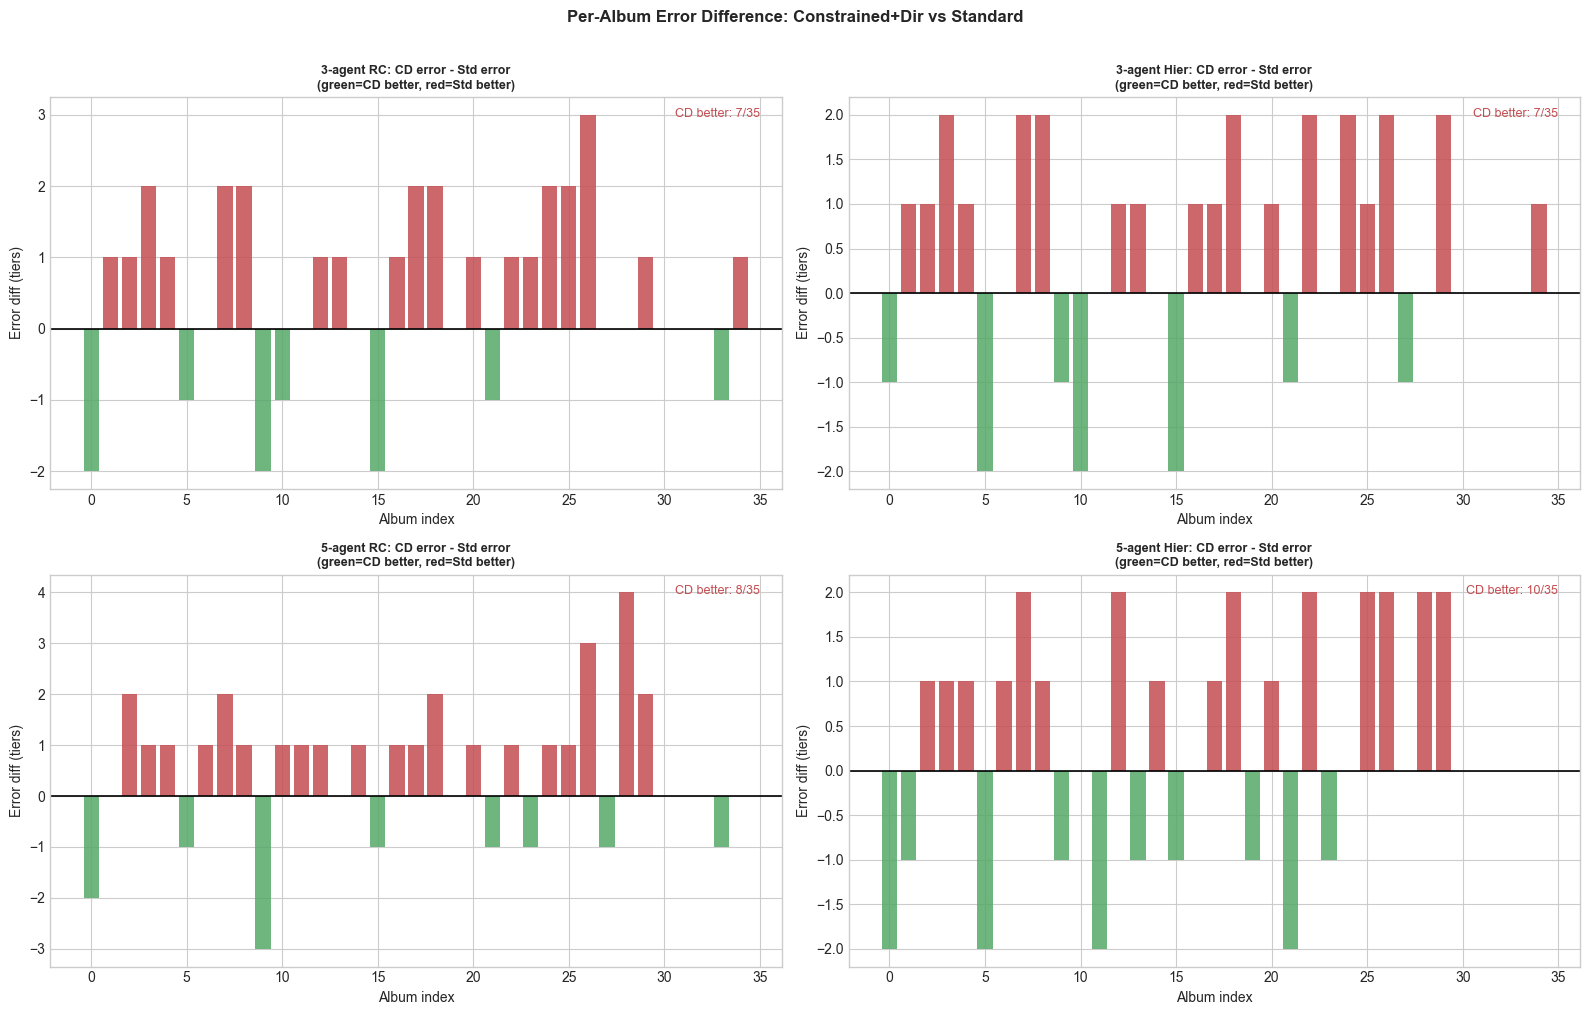

In [40]:
pairs=[('config_a','config_e','3-agent RC'),
       ('config_b','config_f','3-agent Hier'),
       ('config_c','config_g','5-agent RC'),
       ('config_d','config_h','5-agent Hier')]

print(f"{'Pair':<16} {'Std Acc':>9} {'CD Acc':>9} {'Std MAE':>9} {'CD MAE':>9} {'Winner'}")
print('-'*65)
for ka,kb,lbl in pairs:
    sa=cfg_mets[ka]['accuracy']; ca=cfg_mets[kb]['accuracy']
    sm=cfg_mets[ka]['mae'];       cm=cfg_mets[kb]['mae']
    w_acc='CD' if ca>sa else ('Std' if sa>ca else 'Tie')
    print(f'{lbl:<16} {sa:>8.1f}% {ca:>8.1f}% {sm:>9.2f} {cm:>9.2f}  {w_acc}')

# Paired error improvement per album (signed: negative = CD improved)
fig,axes=plt.subplots(2,2,figsize=(16,10))
for ax,(ka,kb,lbl) in zip(axes.flatten(),pairs):
    diffs=[abs(cfg_flat[kb][i]['final_prediction']-cfg_flat[kb][i]['ground_truth'])
           -abs(cfg_flat[ka][i]['final_prediction']-cfg_flat[ka][i]['ground_truth'])
           for i in range(len(all_results))]
    cols_d=['#55A868' if d<0 else ('#C44E52' if d>0 else '#888') for d in diffs]
    ax.bar(range(len(diffs)),diffs,color=cols_d,alpha=0.85)
    ax.axhline(0,color='black',lw=1.2)
    ax.set_title(f'{lbl}: CD error - Std error\n(green=CD better, red=Std better)',
                 fontsize=9,fontweight='bold')
    ax.set_xlabel('Album index'); ax.set_ylabel('Error diff (tiers)')
    improved=sum(d<0 for d in diffs)
    ax.text(0.97,0.95,f'CD better: {improved}/{len(diffs)}',
            transform=ax.transAxes,ha='right',fontsize=9,
            color='#55A868' if improved>len(diffs)/2 else '#C44E52')
plt.suptitle('Per-Album Error Difference: Constrained+Dir vs Standard',
             fontsize=12,fontweight='bold',y=1.01)
plt.tight_layout(); plt.show()

## 10 · Runtime & Cost

Configs per album                                       8
Albums (containers)                                    35
Total evaluations                                     280
Wall-clock time (s)                                  2113
Avg container runtime (s)                           515.7
Max container runtime (s)                           540.2
Total GPU time (s)                                  18048
Total GPU cost (A10G $0.76/hr)                      $3.81
Cost per container                                 $0.109
Cost per evaluation                                $0.014

Counterfactual (8 separate maps, 256 containers): ~$21.08
Saving from combined containers: ~$17.27 (82%)


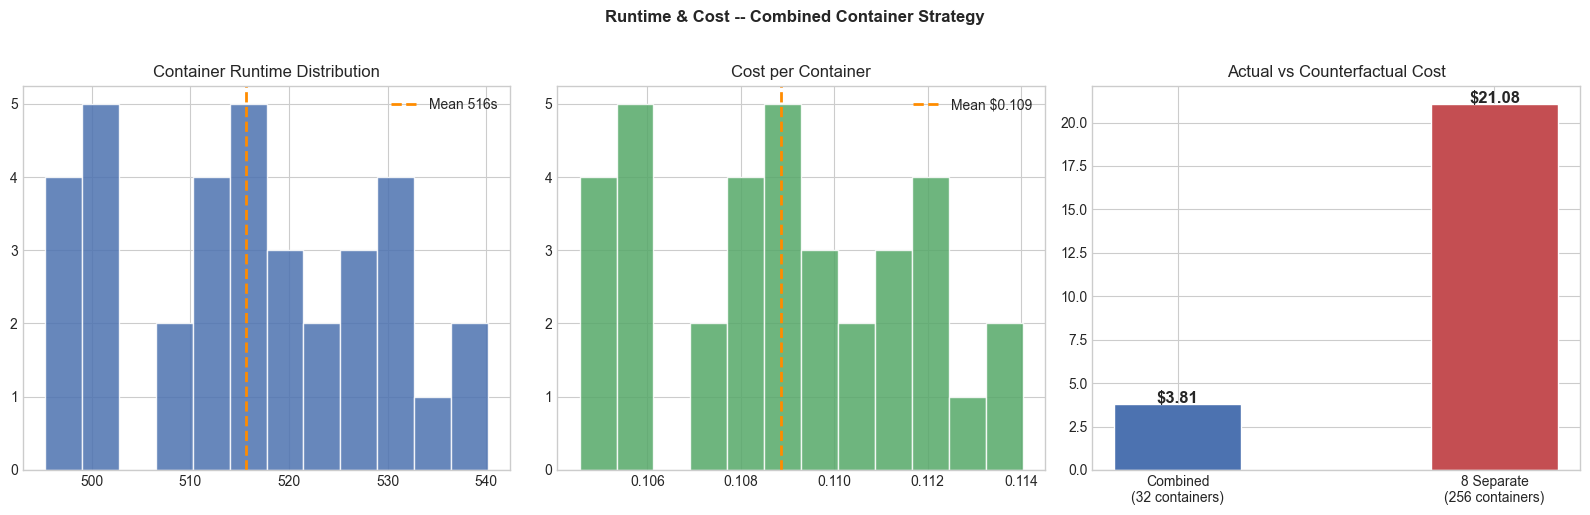

In [41]:
rt_all  =[r['runtime_s']    for r in all_results]
cost_all=[r['gpu_cost_usd'] for r in all_results]
total_cost=sum(cost_all)

print('='*60)
rows=[
    ('Configs per album',8),
    ('Albums (containers)',len(all_results)),
    ('Total evaluations',len(all_results)*8),
    ('Wall-clock time (s)',f'{wall_time:.0f}'),
    ('Avg container runtime (s)',f'{np.mean(rt_all):.1f}'),
    ('Max container runtime (s)',f'{max(rt_all):.1f}'),
    ('Total GPU time (s)',f'{sum(rt_all):.0f}'),
    ('Total GPU cost (A10G $0.76/hr)',f'${total_cost:.2f}'),
    ('Cost per container',f'${np.mean(cost_all):.3f}'),
    ('Cost per evaluation',f'${total_cost/len(all_results)/8:.3f}'),
]
for lbl,val in rows: print(f'{str(lbl):<36} {str(val):>20}')
print('='*60)

# Counterfactual: 8 separate maps x 32 containers
ai=25  # avg inference seconds
cf=32*8*(90+12*ai)*(0.76/3600)  # 12 calls avg per config if run separately
print(f'\nCounterfactual (8 separate maps, 256 containers): ~${cf:.2f}')
print(f'Saving from combined containers: ~${cf-total_cost:.2f} ({(cf-total_cost)/cf*100:.0f}%)')

fig,axes=plt.subplots(1,3,figsize=(16,5))
axes[0].hist(rt_all,bins=12,color='#4C72B0',alpha=0.85,edgecolor='white')
axes[0].axvline(np.mean(rt_all),color='darkorange',ls='--',lw=2,label=f'Mean {np.mean(rt_all):.0f}s')
axes[0].set_title('Container Runtime Distribution'); axes[0].legend()
axes[1].hist(cost_all,bins=12,color='#55A868',alpha=0.85,edgecolor='white')
axes[1].axvline(np.mean(cost_all),color='darkorange',ls='--',lw=2,label=f'Mean ${np.mean(cost_all):.3f}')
axes[1].set_title('Cost per Container'); axes[1].legend()
axes[2].bar(['Combined\n(32 containers)','8 Separate\n(256 containers)'],
            [total_cost,cf],color=['#4C72B0','#C44E52'],width=0.4,edgecolor='white')
axes[2].set_title('Actual vs Counterfactual Cost')
for bar,v in zip(axes[2].patches,[total_cost,cf]):
    axes[2].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.05,
                 f'${v:.2f}',ha='center',fontsize=12,fontweight='bold')
plt.suptitle('Runtime & Cost -- Combined Container Strategy',fontsize=12,fontweight='bold',y=1.02)
plt.tight_layout(); plt.show()

## 11 · Final Summary

In [45]:
print('='*78)
print(f'FULL-SCALE SUMMARY  |  Qwen/Qwen3-VL-8B  |  {len(all_results)} Albums  |  8 Configs')
print('='*78)
print(f"{'Metric':<30}", end='')
for _,lbl,*_ in CONFIG_META: print(f'{lbl[:9]:>10}',end='')
print('\n'+'-'*110)
rows2=[
    ('Agents',                   [3,3,5,5,3,3,5,5]),
    ('Constrained+Dir',          ['No','No','No','No','Yes','Yes','Yes','Yes']),
    ('Exact accuracy (%)',        [round(cfg_mets[k]['accuracy'],1)   for k,*_ in CONFIG_META]),
    ('Off-by-one accuracy (%)',   [round(cfg_mets[k]['off_by_one'],1) for k,*_ in CONFIG_META]),
    ('MAE (tiers)',               [round(cfg_mets[k]['mae'],2)        for k,*_ in CONFIG_META]),
    ('% albums R3>R1',           [round(pcts[k],1)                   for k,*_ in CONFIG_META]),
]
for lbl,vals in rows2:
    print(f'{lbl:<30}',end='')
    for v in vals: print(f'{str(v):>10}',end='')
    print()
print('-'*110)
print(f"{'Total GPU cost':<30} {'$'+str(round(total_cost,2)):>10}")
print(f"{'Wall-clock time (s)':<30} {str(round(wall_time,0)):>10}")
print('='*78)

best_acc=max(CONFIG_META,key=lambda x:cfg_mets[x[0]]['accuracy'])
best_mae=min(CONFIG_META,key=lambda x:cfg_mets[x[0]]['mae'])
print(f'\nKey findings:')
print(f'  Highest exact accuracy  -> {best_acc[1]} ({cfg_mets[best_acc[0]]["accuracy"]:.1f}%)')
print(f'  Lowest MAE              -> {best_mae[1]} ({cfg_mets[best_mae[0]]["mae"]:.2f} tiers)')
print(f'  Standard avg accuracy   -> {np.mean([cfg_mets[k]["accuracy"] for k in ["config_a","config_b","config_c","config_d"]]):.1f}%')
print(f'  Constrained avg accuracy-> {np.mean([cfg_mets[k]["accuracy"] for k in ["config_e","config_f","config_g","config_h"]]):.1f}%')
print(f'  3-agent avg accuracy    -> {np.mean([cfg_mets[k]["accuracy"] for k in ["config_a","config_b","config_e","config_f"]]):.1f}%')
print(f'  5-agent avg accuracy    -> {np.mean([cfg_mets[k]["accuracy"] for k in ["config_c","config_d","config_g","config_h"]]):.1f}%')
print(f'  RC avg accuracy         -> {np.mean([cfg_mets[k]["accuracy"] for k in ["config_a","config_c","config_e","config_g"]]):.1f}%')
print(f'  Hierarchical avg acc    -> {np.mean([cfg_mets[k]["accuracy"] for k in ["config_b","config_d","config_f","config_h"]]):.1f}%')

FULL-SCALE SUMMARY  |  Qwen/Qwen3-VL-8B  |  35 Albums  |  8 Configs
Metric                           A: 3-RC B: 3-Hier   C: 5-RC D: 5-Hier  E: 3-RC+ F: 3-Hier  G: 5-RC+ H: 5-Hier
--------------------------------------------------------------------------------------------------------------
Agents                                 3         3         5         5         3         3         5         5
Constrained+Dir                       No        No        No        No       Yes       Yes       Yes       Yes
Exact accuracy (%)                  31.4      31.4      34.3      31.4      14.3      14.3      14.3      20.0
Off-by-one accuracy (%)             77.1      74.3      74.3      74.3      48.6      51.4      57.1      60.0
MAE (tiers)                         0.94      0.97      0.97      1.03      1.46      1.43      1.49      1.31
% albums R3>R1                      22.9      17.1      25.7      22.9      17.1      17.1      28.6      28.6
--------------------------------------------

---
## 12 · Baseline: Claude Sonnet 4.6 Single Judge

One Anthropic API call per album — no deliberation, no agents. Same three input modalities
(textual description, cover image, audio features) as the Qwen multi-agent configs.
Serves as a cost-and-accuracy reference point.

In [17]:
%pip install -q anthropic


Note: you may need to restart the kernel to use updated packages.


In [18]:
import anthropic, re as _re

# ── Model & pricing ───────────────────────────────────────────────────────────
JUDGE_MODEL          = 'claude-sonnet-4-6'   # verify exact API model string
PRICE_IN_PER_MTOK    = 3.00                  # $ per million input tokens
PRICE_OUT_PER_MTOK   = 15.00                 # $ per million output tokens

_TIER_DEF = (
    'Tier 1: Underground/Cult  (< 100K plays)\n'
    'Tier 2: Indie Success     (100K-1M plays)\n'
    'Tier 3: Moderate Hit      (1M-10M plays)\n'
    'Tier 4: Major Success     (10M-100M plays)\n'
    'Tier 5: Cultural Phenom   (> 100M plays)'
)

def _media_type(b64_str):
    """Detect image media type from base64 magic bytes."""
    import base64
    try:
        hdr = base64.b64decode(b64_str[:16])
        if hdr[:4] == b'\x89PNG': return 'image/png'
        if hdr[:3] == b'GIF': return 'image/gif'
        if hdr[:4] == b'RIFF': return 'image/webp'
    except Exception:
        pass
    return 'image/jpeg'

def judge_album(d, client):
    prompt = (
        f'You are a music industry expert predicting the commercial success of an album.\n\n'
        f'Artist: {d["artist"]}  |  Title: {d["title"]}  |  Year: {d["release_year"]}\n'
        f'Genres: {", ".join(d["genres"])}\nDescription: {d["description"]}\n\n'
        f'Audio Features (0-100 scale, tempo in BPM):\n{d["audio_text"]}\n\n'
        f'{_TIER_DEF}\n\n'
        f'Using the cover image, textual description, and audio features, predict the commercial '
        f'success tier for this album.\n'
        f'Respond in EXACTLY this format:\nTIER: [1-5]\nARGUMENT: [~80 words]'
    )
    content = []
    if d.get('cover_b64'):
        content.append({
            'type': 'image',
            'source': {
                'type': 'base64',
                'media_type': _media_type(d['cover_b64']),
                'data': d['cover_b64'],
            }
        })
    content.append({'type': 'text', 'text': prompt})

    resp = client.messages.create(
        model=JUDGE_MODEL, max_tokens=300,
        messages=[{'role': 'user', 'content': content}]
    )
    text = resp.content[0].text
    tier = 3
    for line in text.split('\n'):
        if line.strip().startswith('TIER:'):
            m = _re.search(r'(\d)', line.split('TIER:', 1)[1])
            if m: tier = int(m.group(1))
    return {
        'tier': tier, 'argument': text,
        'in_tok': resp.usage.input_tokens,
        'out_tok': resp.usage.output_tokens,
    }

print(f'Judge function defined  (model={JUDGE_MODEL})')


Judge function defined  (model=claude-sonnet-4-6)


In [ ]:
import os
os.environ['ANTHROPIC_API_KEY'] = 'YOUR-API-KEY'

In [28]:
# Run Claude judge on all albums (serial — takes ~1-2 min)
_client = anthropic.Anthropic()
judge_results = []
_t0 = time.time()

for d in albums_serial:
    r = judge_album(d, _client)
    row = {
        'album_id':    d['album_id'],
        'album_label': f"{d['artist']} - {d['title']}",
        'ground_truth': d['ground_truth'],
        'genres':       d['genres'],
        'prediction':   r['tier'],
        'argument':     r['argument'],
        'gap':          abs(r['tier'] - d['ground_truth']),
        'in_tok':       r['in_tok'],
        'out_tok':      r['out_tok'],
    }
    judge_results.append(row)
    print(f"  {d['album_id']:<32} GT:{d['ground_truth']} → {r['tier']}  "
          f"gap={row['gap']}  tok={r['in_tok']}+{r['out_tok']}")

print(f'\nDone in {time.time()-_t0:.0f}s  |  {len(judge_results)} albums judged')


  032                              GT:2 → 4  gap=2  tok=631+137
  060                              GT:3 → 4  gap=1  tok=539+127
  034                              GT:3 → 2  gap=1  tok=526+143
  028                              GT:3 → 3  gap=0  tok=520+129
  062                              GT:3 → 4  gap=1  tok=497+131
  011                              GT:3 → 3  gap=0  tok=555+138
  039                              GT:2 → 2  gap=0  tok=457+126
  047                              GT:3 → 5  gap=2  tok=480+132
  024                              GT:2 → 3  gap=1  tok=531+118
  031                              GT:2 → 3  gap=1  tok=576+130
  017                              GT:2 → 2  gap=0  tok=567+139
  029                              GT:3 → 2  gap=1  tok=666+135
  022                              GT:2 → 3  gap=1  tok=654+131
  015                              GT:3 → 4  gap=1  tok=539+135
  013                              GT:4 → 4  gap=0  tok=540+131
  030                              GT:2 

CLAUDE claude-sonnet-4-6 BASELINE  |  n=35 albums
  Exact accuracy    (gap=0):   37.1%  (13/35)
  One-off accuracy  (gap=1):   51.4%  (18/35)
  Within-1 accuracy (gap≤1):   88.6%  (31/35)
  Mean absolute error:        0.743

  Total input  tokens:    18,587
  Total output tokens:     4,638
  Total cost:           $0.1253

  Largest prediction gap:
    Disturbed - Evolution
    Ground truth: Tier 2  |  Predicted: Tier 4  |  Gap: 2
    TIER: 4

ARGUMENT: Disturbed's *Evolution* demonstrates strong commercial indicators across multiple dimensions. The band's proven track record (six consecutive top-5 Billboard albums) establishes a massive existing fanbase. The cover art's professional DNA helix design signals a high-budget major l


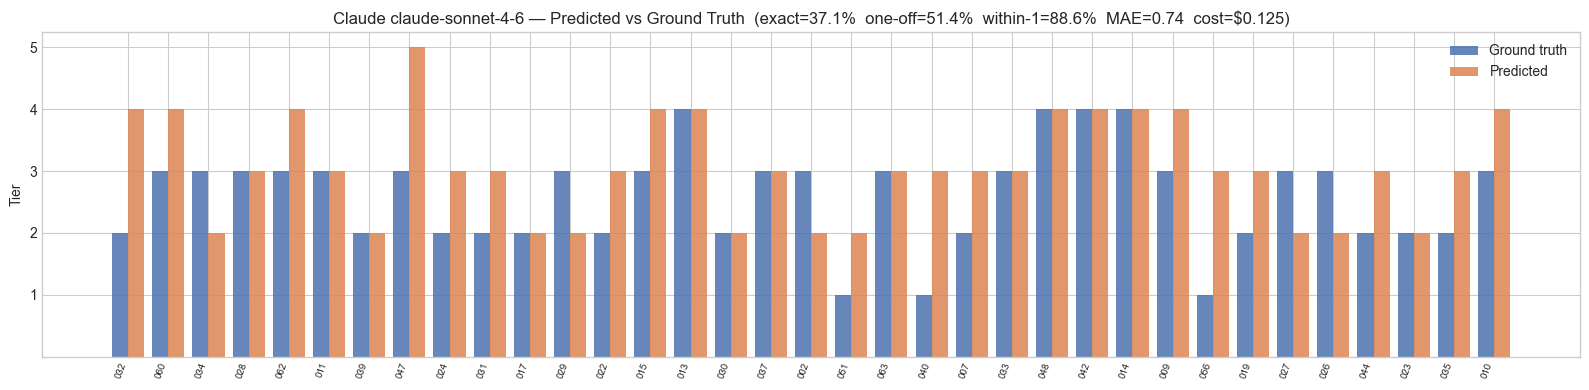

In [29]:
import matplotlib.pyplot as plt
import numpy as np

n        = len(judge_results)
exact    = sum(1 for r in judge_results if r['gap'] == 0)
one_off  = sum(1 for r in judge_results if r['gap'] == 1)
within1  = sum(1 for r in judge_results if r['gap'] <= 1)
mae      = sum(r['gap'] for r in judge_results) / n
worst    = max(judge_results, key=lambda r: r['gap'])

total_in   = sum(r['in_tok']  for r in judge_results)
total_out  = sum(r['out_tok'] for r in judge_results)
total_cost = (total_in * PRICE_IN_PER_MTOK + total_out * PRICE_OUT_PER_MTOK) / 1_000_000

# ── Print report ──────────────────────────────────────────────────────────────
print('='*60)
print(f'CLAUDE {JUDGE_MODEL} BASELINE  |  n={n} albums')
print('='*60)
print(f'  Exact accuracy    (gap=0):  {exact/n*100:5.1f}%  ({exact}/{n})')
print(f'  One-off accuracy  (gap=1):  {one_off/n*100:5.1f}%  ({one_off}/{n})')
print(f'  Within-1 accuracy (gap≤1):  {within1/n*100:5.1f}%  ({within1}/{n})')
print(f'  Mean absolute error:        {mae:.3f}')
print()
print(f'  Total input  tokens:  {total_in:>8,}')
print(f'  Total output tokens:  {total_out:>8,}')
print(f'  Total cost:           ${total_cost:.4f}')
print()
print(f'  Largest prediction gap:')
print(f'    {worst["album_label"]}')
print(f'    Ground truth: Tier {worst["ground_truth"]}  |  '
      f'Predicted: Tier {worst["prediction"]}  |  Gap: {worst["gap"]}')
print(f'    {worst["argument"].strip()[:300]}')
print('='*60)

# ── Bar chart: GT vs predicted tier per album ─────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
x = np.arange(n)
ax.bar(x - 0.2, [r['ground_truth'] for r in judge_results], 0.4,
       label='Ground truth', color='#4C72B0', alpha=0.85)
ax.bar(x + 0.2, [r['prediction']   for r in judge_results], 0.4,
       label='Predicted',    color='#DD8452', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([r['album_id'] for r in judge_results],
                   rotation=70, ha='right', fontsize=7)
ax.set_yticks(range(1, 6))
ax.set_ylabel('Tier')
ax.set_title(f'Claude {JUDGE_MODEL} — Predicted vs Ground Truth  '
             f'(exact={exact/n*100:.1f}%  one-off={one_off/n*100:.1f}%  '
             f'within-1={within1/n*100:.1f}%  MAE={mae:.2f}  cost=${total_cost:.3f})')
ax.legend()
plt.tight_layout()
plt.show()
